# ARCANE Self-Healing Pipeline — v3

Multi-modal UI element recovery using:
-  Semantic Embeddings (all-MiniLM-L6-v2)
-  Contextual Tag/ARIA matching
-  Textual TF-IDF similarity
-  Visual SSIM comparison
-  AI Vision (EfficientNet-B0 CNN features)

## Tunnel Architecture
- **Ngrok** (`arcane-healer.ngrok-free.app`) → Colab Flask API (static, never changes)
-  **localhost.run** (`9aee8785fc2dc2.lhr.life`) → local `arcane-shop.html` on port 8085 (run: `ssh -R 80:localhost:8085 localhost.run`)
- **Angular Dashboard** → polls ngrok `/dashboard-data` and `/analytics`

## API Endpoints
- `POST /heal` — run healing pipeline
- `GET  /dashboard-data` — latest run details
- `GET  /analytics` — aggregated analytics  
- `GET  /history` — run history (SQLite)
- `GET  /ping` — health check


In [1]:
# ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
#  CELL 0   STARTUP : RAM + DRIVE MOUNT + PERSISTENT STORAGE
# ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
import psutil, os, shutil
from google.colab import drive
#    1. MOUNT DRIVE ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
DRIVE_ROOT  = "/content/drive"
DRIVE_MY    = f"{DRIVE_ROOT}/MyDrive"
if not os.path.exists(DRIVE_MY):
    print(" Mounting Google Drive...")
    drive.mount(DRIVE_ROOT)
else:
    print(" Google Drive already mounted.")
#    2. PERSISTENT PATHS (survive Colab restarts) ─────────────────────────────────────
DRIVE_DATA   = f"{DRIVE_MY}/heal_data"
DRIVE_CROPS  = f"{DRIVE_DATA}/crops"
os.makedirs(DRIVE_DATA,  exist_ok=True)
os.makedirs(DRIVE_CROPS, exist_ok=True)
DB_PATH      = f"{DRIVE_DATA}/heal_history.db"
print(f" Persistent DB  : {DB_PATH}")
print(f" Persistent dir : {DRIVE_CROPS}")
#    3. RAM STATUS ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
def ram_status(label=""):
    r = psutil.virtual_memory()
    bar = " " * int(r.percent / 5) + " " * (20 - int(r.percent / 5))
    print(f"\nRAM {label}: {r.used/1e9:.1f}/{r.total/1e9:.1f} GB  [{bar}] {r.percent:.0f}%")
    if r.percent > 85:
        print("  DANGER   free RAM before continuing.")
ram_status("at startup")
print("\n   Ready. Launch Cell 2.")

 Mounting Google Drive...
Mounted at /content/drive
 Persistent DB  : /content/drive/MyDrive/heal_data/heal_history.db
 Persistent dir : /content/drive/MyDrive/heal_data/crops

RAM at startup: 2.3/13.6 GB  [                    ] 19%

   Ready. Launch Cell 2.


#  Self-Healing Selector Pipeline
Multi-modal UI element recovery using semantic embeddings, TF-IDF, and SSIM.


In [2]:
!playwright install chromium

/bin/bash: line 1: playwright: command not found


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLATION SANS RESTART
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys, importlib, importlib.metadata, os, time
# ── helpers ───────────────────────────────────────────────────────────────────
def _run(cmd, silent=True):
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if not silent and res.returncode != 0:
        print(f"  ⚠ {cmd[:80]}\n  {res.stderr[-200:]}")
    return res.returncode == 0
def _ver(pkg):
    try:    return importlib.metadata.version(pkg)
    except: return None
def _need_install():
    PINNED = {"transformers": "4.37.2", "sentence-transformers": "2.6.1", "accelerate": "0.27.2"}
    PRESENT = ["sentencepiece","sacremoses","flask","flask-cors","pyngrok",
                "opencv-python","scikit-learn","scikit-image","playwright","nest-asyncio",
                "torch","torchvision"]
    for pkg, ver in PINNED.items():
        if _ver(pkg) != ver:
            print(f"  ↻  {pkg}: {_ver(pkg) or 'absent'} → {ver}")
            return True
    for pkg in PRESENT:
        if _ver(pkg) is None:
            print(f"  ↻  {pkg}: absent")
            return True
    # test imports réels
    try:
        from transformers.pytorch_utils import find_pruneable_heads_and_indices
        from sentence_transformers import SentenceTransformer
        import flask, cv2, sklearn, skimage, pyngrok, playwright, nest_asyncio
        return False
    except ImportError as e:
        print(f"  ↻  import échoué : {e}")
        return True
# ── install ───────────────────────────────────────────────────────────────────
if not _need_install():
    print("  ✓  Toutes les librairies sont OK — rien à installer.")
else:
    print("   Installation en cours (sans restart)...\n")
    print("  [1/5] Désinstallation des conflits...")
    _run("pip uninstall -y transformers sentence-transformers peft accelerate sentencepiece sacremoses 2>/dev/null")
    print("  [2/5] Pinned core deps...")
    _run("pip install accelerate==0.27.2 --quiet --no-cache-dir")
    _run("pip install transformers==4.37.2 --quiet --no-cache-dir")
    _run("pip install sentence-transformers==2.6.1 --quiet --no-cache-dir")
    _run("pip install sentencepiece sacremoses --quiet --no-cache-dir")
    print("  [3/5] ML / CV / web stack...")
    _run("pip install playwright opencv-python matplotlib scikit-image scikit-learn nest-asyncio --quiet")
    _run("pip install flask flask-cors pyngrok requests --quiet")
    print("  [4/5] System packages Chromium...")
    _run("apt-get update -y -qq")
    _run("apt-get install -y -qq libnss3 libatk-bridge2.0-0 libgtk-3-0 libxss1 libasound2 libgbm1 libxshmfence1 libglu1-mesa libatk1.0-0")
    print("  [5/5] Playwright Chromium...")
    _run("playwright install chromium")
    print("  [5b/5] PyTorch + torchvision...")
    _run("pip install torch torchvision --quiet --no-cache-dir")
    # ── Recharger les modules dans le kernel courant (évite le restart) ───────
    print("\n  ♻  Rechargement des modules dans le kernel...")
    _RELOAD_ORDER = [
        "accelerate", "transformers", "sentence_transformers",
        "sentencepiece", "flask", "flask_cors", "pyngrok",
        "cv2", "sklearn", "skimage", "playwright", "nest_asyncio",
    ]
    for mod_name in _RELOAD_ORDER:
        if mod_name in sys.modules:
            try:
                importlib.reload(sys.modules[mod_name])
            except Exception:
                pass  # certains modules ne supportent pas reload — pas grave
    # Invalider le cache de métadonnées de pip pour que _ver() retourne les bonnes versions
    importlib.invalidate_caches()
    print("\n ✓   Installation terminée — kernel intact, Run All peut continuer.")
# ── vérification finale ───────────────────────────────────────────────────────
print()
for pkg, expected in [("transformers","4.37.2"), ("sentence-transformers","2.6.1"), ("accelerate","0.27.2")]:
    got = _ver(pkg)
    status = "✓" if got == expected else "⚠ "
    print(f"  {status}  {pkg}: {got}")
print()
print("  ⏭  Proceed to Cell 2.")

  ↻  transformers: 5.12.0 → 4.37.2
   Installation en cours (sans restart)...

  [1/5] Désinstallation des conflits...
  [2/5] Pinned core deps...
  [3/5] ML / CV / web stack...
  [4/5] System packages Chromium...
  [5/5] Playwright Chromium...
  [5b/5] PyTorch + torchvision...

  ♻  Rechargement des modules dans le kernel...

 ✓   Installation terminée — kernel intact, Run All peut continuer.

  ✓  transformers: 4.37.2
  ✓  sentence-transformers: 2.6.1
  ✓  accelerate: 0.27.2

  ⏭  Proceed to Cell 2.


##  Cell 2 — Configuration & Model Loading

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 2 — CACHE + CONFIG + MODELS
# ══════════════════════════════════════════════════════════════════════════════
import os, sys, re, cv2, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Optional
from skimage.metrics import structural_similarity as ssim
# ── GDRIVE CACHE ─────────────────────────────────────────────────────────────
# Drive est déjà monté par Cell 0 — on réutilise silencieusement.
GDRIVE_CACHE    = "/content/drive/MyDrive/colab_model_cache"
DRIVE_MY        = "/content/drive/MyDrive"
if not os.path.exists(DRIVE_MY):
    # Sécurité : si Cell 0 n'a pas été lancée, on remonte Drive.
    from google.colab import drive
    drive.mount("/content/drive")
os.makedirs(GDRIVE_CACHE, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"]         = GDRIVE_CACHE
os.environ["HF_HOME"]                    = GDRIVE_CACHE
os.environ["HF_DATASETS_CACHE"]          = GDRIVE_CACHE
os.environ["SENTENCE_TRANSFORMERS_HOME"] = GDRIVE_CACHE
print(f" Cache Drive actif → {GDRIVE_CACHE}")
# ── PERSISTENT PATHS (fallback if Cell 0 not run) ───────────────
DRIVE_DATA  = DRIVE_DATA  if "DRIVE_DATA"  in dir() else "/content/drive/MyDrive/heal_data"
DRIVE_CROPS = DRIVE_CROPS if "DRIVE_CROPS" in dir() else f"{DRIVE_DATA}/crops"
DB_PATH     = DB_PATH     if "DB_PATH"     in dir() else f"{DRIVE_DATA}/heal_history.db"
os.makedirs(DRIVE_DATA,  exist_ok=True)
os.makedirs(DRIVE_CROPS, exist_ok=True)
print(f" Persistent crop dir: {DRIVE_CROPS}")
# ── USER CONFIG ───────────────────────────────────────────────────────────────
URL            = "https://e009ea61ffc233.lhr.life/arcane-shop.html"
BYPASS_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
}
BASELINE_TEXT          = "#SHHOP"
CONFIDENCE_THRESHOLD   = 0.55
# ── FUSION WEIGHTS (rebalanced to fix score dilution) ─────────────────────
# Each stage blends its own signal into the running score via:
#   score = (1 - w) * previous_score + w * new_signal
# With the old weights (0.35 / 0.40 / 0.40 / 0.40), the original semantic
# score retained only ~14% weight by the end of the funnel — too diluted,
# causing many correct matches to fall below CONFIDENCE_THRESHOLD.
# New weights restore the semantic score to ~35% of the final blend.
CONTEXTUAL_WEIGHT = 0.35
TFIDF_WEIGHT      = 0.25
VISUAL_WEIGHT     = 0.15
AI_VISION_WEIGHT  = 0.15
USE_FRENCH_TRANSLATION = False
BASELINE_FILE          = "/content/baseline.json"
IMAGE_FILE             = "/content/baseline.png"
# ── NGROK TOKEN — lu depuis Colab Secrets     ───────────────────────────────
try:
    from google.colab import userdata
    NGROK_TOKEN = userdata.get('NGROK_TOKEN') or os.environ.get('NGROK_TOKEN', '')
except Exception:
    NGROK_TOKEN = os.environ.get('NGROK_TOKEN', '')
if not NGROK_TOKEN:
    print("  NGROK_TOKEN absent — ajoute-le dans Colab Secrets.")
else:
    print(" ✓ NGROK_TOKEN chargé.")
# ── IMPORTS: sentence-transformers ────────────────────────────────────────────
import subprocess
def run_pip_install(package):
    print(f"  Installing {package}...")
    res = subprocess.run(
        [sys.executable, "-m", "pip", "install", package, "--quiet"],
        capture_output=True, text=True
    )
    if res.returncode != 0:
        print(f"WARNING: Failed to install {package}: {res.stderr}")
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.feature_extraction.text import TfidfVectorizer
    print("  sentence-transformers already available — skipping install.")
except ImportError:
    run_pip_install("sentence-transformers==2.6.1")
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.feature_extraction.text import TfidfVectorizer
import asyncio
import nest_asyncio
from playwright.async_api import async_playwright
warnings.filterwarnings("ignore")
nest_asyncio.apply()
# ── MATPLOTLIB DARK THEME ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2e3250", "axes.labelcolor": "#c9d1d9",
    "axes.titlecolor": "#ffffff", "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.grid": True, "grid.color": "#2e3250", "grid.linewidth": 0.6,
    "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "text.color": "#c9d1d9", "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#2e3250", "legend.fontsize": 9,
    "lines.linewidth": 2, "figure.titlesize": 15, "figure.titleweight": "bold",
})
PALETTE = ["#7c6af7", "#3ecf8e", "#f59e0b", "#ef4444", "#38bdf8", "#ec4899"]
# ── UI VOCABULARY ─────────────────────────────────────────────────────────────
_UI_VOCAB = [
    "password","username","email","button","input","text",
    "checkbox","radio","form","label","navigation","authentication",
    "message","error","confirm","address","telephone","number",
    "image","link","submit","search","login","logout","register",
    "dropdown","modal","header","footer","menu","icon","avatar",
    "profile","settings","dashboard","notification","upload","download",
    "cancel","delete","edit","save","close","open","next","previous",
    "back","home","help","about","contact","terms","privacy","filter",
    "apply","reset","sort","table","row","column","pagination","tab",
    "banner","logo","promo","hero","countdown","featured","arrivals",
    "sale","cart","wishlist","checkout","newsletter","shipping",
    "discount","subtotal","total","size","picker","review",
    "grid","panel","items","category","quick","search","tag",
    "backpack","confirmation","order","number","display","name",
    "address","phone","lastname","firstname","continue","payment",
    "gadget","tech","filter",
]
_UI_VOCAB_VECS = None
# ── WORDS TO NEVER EXPAND ─────────────────────────────────────────────────────
_PRESERVE = {
    "flag","submit","login","logout","filter","apply","reset",
    "delete","edit","save","cancel","search","upload","download",
    "close","open","next","back","home","help","sort","nav",
    "btn","form","modal","tab","row","col","add","new","old",
}
# ── SEMANTIC MODEL ────────────────────────────────────────────────────────────
print("\nLoading semantic model (all-MiniLM-L6-v2)...")
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")
embedding_cache = {}
def get_embedding(text: str) -> np.ndarray:
    if not text:
        return np.zeros(384)
    if text not in embedding_cache:
        embedding_cache[text] = semantic_model.encode(text)
    return embedding_cache[text]
def _vocab_vecs():
    global _UI_VOCAB_VECS
    if _UI_VOCAB_VECS is None:
        _UI_VOCAB_VECS = semantic_model.encode(_UI_VOCAB, show_progress_bar=False)
    return _UI_VOCAB_VECS
def _is_known_word(word: str) -> bool:
    return len(word) > 5 and sum(1 for c in word.lower() if c in "aeiou") >= 2
def expand_abbreviations(text: str) -> str:
    words, result = text.lower().split(), []
    for word in words:
        if word in _PRESERVE:
            result.append(word)
            continue
        if _is_known_word(word):
            result.append(word)
            continue
        scores = cosine_similarity([get_embedding(word)], _vocab_vecs())[0]
        best_i = int(np.argmax(scores))
        if float(scores[best_i]) >= 0.55:
            expanded = _UI_VOCAB[best_i]
            print(f"  Abbrev: '{word}' → '{expanded}' ({scores[best_i]:.3f})")
            result.append(expanded)
        else:
            result.append(word)
    return " ".join(result)
# ── TRANSLATION — lazy load ───────────────────────────────────────────────────
_tok = None
_mdl = None
fr_en_translator = None
def _load_translation_model():
    global _tok, _mdl, fr_en_translator
    if fr_en_translator is not None:
        return
    MODEL_NAME = "Helsinki-NLP/opus-mt-fr-en"
    model_cached = any(
        "opus-mt-fr-en" in d
        for d in os.listdir(GDRIVE_CACHE)
        if os.path.isdir(os.path.join(GDRIVE_CACHE, d))
    ) if os.path.exists(GDRIVE_CACHE) else False
    if model_cached:
        print("  Translation model: loading from Drive cache...")
    else:
        print("  Translation model: downloading...")
    from transformers import MarianMTModel, MarianTokenizer
    import torch
    _tok = MarianTokenizer.from_pretrained(MODEL_NAME)
    _mdl = MarianMTModel.from_pretrained(MODEL_NAME)
    def _translate(text: str) -> str:
        inputs = _tok([text], return_tensors="pt", padding=True)
        with torch.no_grad():
            out = _mdl.generate(**inputs)
        return _tok.decode(out[0], skip_special_tokens=True)
    fr_en_translator = _translate
    print(" ✓ Translation model ready.")
_FR_WORDS = {
    "appliquer","filtrer","connexion","mot","passe","soumettre","rechercher",
    "annuler","confirmer","supprimer","modifier","nom","prénom","adresse",
    "téléphone","envoyer","valider","retour","suivant","précédent","accueil",
}
def translate_if_needed(text: str) -> str:
    if not USE_FRENCH_TRANSLATION:
        return text
    clean = re.sub(r'[#\-_/]', ' ', text.lower()).split()
    needs_translation = bool(set(clean) & _FR_WORDS)
    if not needs_translation:
        return text
    _load_translation_model()
    try:
        t = fr_en_translator(text)
        if t.lower() != text.lower():
            print(f" ✓ Translated: '{text}' → '{t}'")
            return t
    except Exception as e:
        print(f"  Translation error: {e}")
    return text
# ── PROCESS BASELINE TEXT ─────────────────────────────────────────────────────
_bt = translate_if_needed(BASELINE_TEXT)
BASELINE_TEXT_EXPANDED = expand_abbreviations(_bt)
BASELINE_VEC           = get_embedding(BASELINE_TEXT_EXPANDED)
print(f"\nOriginal BASELINE_TEXT : '{BASELINE_TEXT}'")
print(f"Expanded for embedding  : '{BASELINE_TEXT_EXPANDED}'")
print("\n ✓ Cell 2 complete.")

 Cache Drive actif → /content/drive/MyDrive/colab_model_cache
 Persistent crop dir: /content/drive/MyDrive/heal_data/crops
 ✓ NGROK_TOKEN chargé.


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


  sentence-transformers already available — skipping install.

Loading semantic model (all-MiniLM-L6-v2)...

Original BASELINE_TEXT : '#SHHOP'
Expanded for embedding  : '#shhop'

 ✓ Cell 2 complete.


##  Cell 3 — Preprocessing, Extraction & Persistence Helpers

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 3 : HELPERS
# ══════════════════════════════════════════════════════════════════════════════
# ── TEXT PREPROCESSING ────────────────────────────────────────────────────────
def preprocess(text: str) -> str:
    if not text: return ""
    text = text.lower()
    text = re.sub(r'[_\-/]', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()
_GENERIC_TAGS = {"div","span","button","input","a","section","aside","nav","header","footer","main","label","select","textarea"}
def element_to_text(el: dict) -> str:
    parts = [el.get(k, "") for k in ("text","id","class","name","placeholder","input_type")]
    tag = el.get("tag", "")
    if tag and tag not in _GENERIC_TAGS:
        parts.append(tag)
    text = " ".join(preprocess(p) for p in parts if p)
    el_id = el.get("id", "")
    if el_id:
        clean_id = preprocess(el_id)
        text = text + " " + clean_id
    return text
# ── VISIBILITY FILTER ─────────────────────────────────────────────────────────
def is_visible(el: dict) -> bool:
    if el.get("input_type", "").lower() == "hidden": return False
    w, h = el.get("width", 0), el.get("height", 0)
    x, y = el.get("x", 0), el.get("y", 0)
    return not (w <= 0 or h <= 0 or x < 0 or y < 0 or w < 5 or h < 5)
# ── ELEMENT EXTRACTION ────────────────────────────────────────────────────────
async def extract_elements(page) -> list[dict]:
    SELECTOR = (
    "button, input, a, select, textarea, label, "
    "div[role], span[role], "
    "div[id], div[data-testid], span[id], span[data-testid], "
    "[aria-label]"
    )
    raw = await page.query_selector_all(SELECTOR)
    data, skipped = [], 0
    for el in raw:
        try:
            box = await el.bounding_box()
            tag  = await el.evaluate("e => e.tagName.toLowerCase()")
            text = (await el.text_content()) or ""
            entry = {
                "tag": tag, "text": text.strip(),
                "id":          await el.get_attribute("id")          or "",
                "class":       await el.get_attribute("class")       or "",
                "name":        await el.get_attribute("name")        or "",
                "placeholder": await el.get_attribute("placeholder") or "",
                "input_type":  await el.get_attribute("type")        or "",
                "aria_label":  await el.get_attribute("aria-label")  or "",
                "data_testid": await el.get_attribute("data-testid") or "",
                "x": box["x"] if box else 0.0, "y": box["y"] if box else 0.0,
                "width": box["width"] if box else 0.0, "height": box["height"] if box else 0.0,
                "element": el,
            }
            # FIX: previously, elements that were hidden / display:none / closed
            # panels (e.g. #wishlist-panel, #cart-items-list, #modal-title,
            # #search-modal before opening) were dropped here entirely, so the
            # *correct* healing target never reached the candidate pool. Keep
            # every matched element and tag it with "visible" instead, so later
            # stages can still find it via semantic/contextual/textual matching
            # without being penalized for the missing screenshot.
            try:
                entry["visible"] = await el.is_visible()
            except Exception:
                entry["visible"] = is_visible(entry)
            data.append(entry)
        except Exception:
            skipped += 1
    n_visible = sum(1 for e in data if e.get("visible", True))
    print(f"  Extracted: {len(data)} total ({n_visible} visible, {len(data)-n_visible} hidden) / {skipped} errors")
    return data
# ── BASELINE PERSISTENCE ──────────────────────────────────────────────────────
def load_baseline():
    if not os.path.exists(BASELINE_FILE): return None
    try:
        with open(BASELINE_FILE) as f: return json.load(f)
    except json.JSONDecodeError:
        print("  Baseline JSON corrupted — ignoring.")
        return None
def save_baseline(el: dict) -> None:
    data = {k: el.get(k, "").strip() if isinstance(el.get(k,""), str) else el.get(k,"")
            for k in ("text","tag","id","class","name","placeholder","input_type")}
    with open(BASELINE_FILE, "w") as f:
        json.dump(data, f, indent=2)
# ── SCORE HELPERS ─────────────────────────────────────────────────────────────
def fuse(base: float, new: float, w: float) -> float:
    """Weighted additive fusion — clamped to [0, 1]."""
    return min(1.0, max(0.0, (1.0 - w) * base + w * new))
def normalize_scores(candidates: list) -> list:
    if not candidates: return []
    return [(el, min(1.0, max(0.0, s))) for el, s in candidates]
# ── SELECTOR PARSING ──────────────────────────────────────────────────────────
def parse_broken_selector(selector: str) -> dict:
    info, s = {}, selector.strip()
    m = re.match(r'^#([\w-]+)$', s)
    if m:
        info['id'] = m.group(1)
        return info
    m = re.match(r'^([\w]+)', s)
    if m:
        t = m.group(1).lower()
        if t not in ('page','get','text'):
            info['tag'] = t
    patterns = [
        (r'\[type=["\']?([\w-]+)["\']?\]', 'input_type'),
        (r'\[name=["\']?([\w-]+)["\']?\]', 'name'),
        (r'\[placeholder=["\']?([^"\']+)["\']?\]', 'placeholder'),
        (r'\[id=["\']?([\w-]+)["\']?\]', 'id'),
        (r'\[data-testid=["\']?([\w-]+)["\']?\]', 'id'),  # treat testid as id for baseline
    ]
    for pattern, key in patterns:
        m = re.search(pattern, s)
        if m:
            info[key] = m.group(1)
    text_patterns = [
        r':has-text\(["\']([^"\']+)["\']\)',
        r'get_by_text\(["\']([^"\']+)["\']\)'
    ]
    for pat in text_patterns:
        m = re.search(pat, s)
        if m:
            info['text'] = m.group(1)
            break
    cls = re.findall(r'\.([\w-]+)', s)
    if cls:
        info['class'] = ' '.join(cls)
    return info
# ── SELECTOR → BASELINE TEXT  — garbage detection + semantic fallback ───
_GARBAGE_TOKENS = {"xyz", "abc", "test", "nonexist", "dummy", "fake", "garbage",
                   "invalid", "bad", "wrong", "missing", "random", "unknown", "undefined"}

def _is_garbage_selector(selector: str) -> bool:
    """Detect selectors like #this-element-does-not-exist-xyz123."""
    tokens = re.sub(r'[#\.\[\]=\'\"\-_ ]', ' ', selector).lower().split()
    garbage_count = sum(1 for t in tokens if t in _GARBAGE_TOKENS or
                        (len(t) >= 6 and t[-3:] in ("123", "999", "000", "abc", "xyz")))
    return (garbage_count >= 1 or
            bool(re.search(r'(xyz\d+|abc\d+|\d{6,})', selector)))

def selector_to_baseline_text(selector: str) -> str:
    if _is_garbage_selector(selector):
        return ""

    # extraire la valeur utile du sélecteur
    testid_match = re.match(r'\[data-testid=["\']([^"\']+)["\']\]', selector.strip())
    if testid_match:
        raw_val = testid_match.group(1)
    else:
        parts = selector.strip().split()
        raw_vals = []
        for part in parts:
            cleaned = re.sub(r'^[#\.\[\]]+', '', part)
            cleaned = re.sub(r'["\'\]]', '', cleaned)
            if cleaned:
                raw_vals.append(cleaned)
        raw_val = ' '.join(raw_vals) if raw_vals else re.sub(r'^[#\.\[]', '', parts[0])

    # Hyphens/underscores → spaces, camelCase → spaces
    raw_val = re.sub(r'[-_]', ' ', raw_val)
    raw_val = re.sub(r'([a-z])([A-Z])', r'\1 \2', raw_val)
    # Strip version suffixes  (old|new|v2|123)
    raw_val = re.sub(r'\s+(old|new|v\d+|\d+)$', '', raw_val, flags=re.IGNORECASE)
    words = [w.lower() for w in raw_val.split() if len(w) > 1 and not w.isdigit()]

    # Fallback : si rien extrait, utiliser l'ancien parse
    if not words:
        clean_selector = re.sub(r'[_-]?(old|new|v\d+|\d+)$', '', selector.strip(), flags=re.IGNORECASE)
        info = parse_broken_selector(clean_selector)
        raw  = ' '.join(filter(None, [info.get(k,'') for k in ('id','class','name','placeholder','text')]))
        raw  = re.sub(r'([a-z])([A-Z])', r'\1 \2', raw)
        raw  = re.sub(r'[-_]', ' ', raw)
        words = [w.lower() for w in raw.split() if len(w) > 1 and not w.isdigit()]

    # Ajouter tag/type sémantique si utile
    info = parse_broken_selector(selector)
    tag_lbl  = {'input':'input','button':'button','a':'link','select':'dropdown',
                'textarea':'textarea','form':'form','label':'label'}
    type_lbl = {'password':'password','email':'email','text':'text','submit':'submit button',
                'checkbox':'checkbox','radio':'radio','search':'search','tel':'telephone',
                'number':'number'}
    for lbl in [tag_lbl.get(info.get('tag','')), type_lbl.get(info.get('input_type',''))]:
        if lbl and lbl not in words:
            words.append(lbl)

    return ' '.join(words) if words else selector

# ── FILTER BUILDER ────────────────────────────────────────────────────────────
def build_selector_filter(info: dict):
    def matches(el: dict) -> bool:
        if info.get('id'):
            ref = set(re.split(r'[-_]', info['id'].lower()))
            got = set(re.split(r'[-_]', el.get('id','').lower()))
            if ref & got - {''}: return True
        if info.get('tag') and info.get('input_type'):
            if el.get('tag') == info['tag'] and el.get('input_type') == info['input_type']:
                return True
        for attr, ek in [('name','name'),('placeholder','placeholder'),('text','text')]:
            rv = info.get(attr,'').lower()
            ev = el.get(ek,'').lower()
            if rv and ev and (rv in ev or ev in rv):
                return True
        if info.get('class'):
            rc = set(info['class'].lower().split())
            ec = set(el.get('class','').lower().split())
            if rc & ec - {'active','focus','hover','disabled',''}:
                return True
        return False
    return matches
print("✓ Cell 3 ready.")

✓ Cell 3 ready.


##  Cell 4 — 4-Stage Pipeline

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 4 : PIPELINE STAGES
# ══════════════════════════════════════════════════════════════════════════════
#
# Stage funnel: ALL → top-15 (semantic) → top-8 (contextual)
#               → top-5 (textual/TF-IDF) → ranked (visual/SSIM blended)
#  FIX: top-3 was too narrow for visual recovery; raised to top-5.
#  FIX: normalize_scores() now applied after each stage so fuse() stays in [0,1].
# ── STAGE 1 : SEMANTIC ───────────────────────────────────────────────────────
def semantic_stage(elements: list, history: dict,
                   baseline_vec: np.ndarray,
                   bt_expanded: str) -> list:
    t0    = time.time()
    texts = [element_to_text(el) for el in elements]
    uncached = [t for t in texts if t and t not in embedding_cache]
    if uncached:
        vecs = semantic_model.encode(uncached, batch_size=64, show_progress_bar=False)
        for t, v in zip(uncached, vecs): embedding_cache[t] = v
    results = []
    raw_scores = []
    for el, text in zip(elements, texts):
        score = float(cosine_similarity([baseline_vec], [get_embedding(text)])[0][0])
        raw_scores.append(score)
        results.append((el, score))
    history["semantic_raw"] = sorted(raw_scores, reverse=True)
    results = normalize_scores(results)
    history["semantic"] = sorted([s for _, s in results], reverse=True)
    print(f"  Semantic  : {len(results)} candidates  ({time.time()-t0:.2f}s)")
    return results
# ── STAGE 2 : CONTEXTUAL ─────────────────────────────────────────────────────
def contextual_stage(candidates: list, history: dict, bt_expanded: str) -> list:
    t0, bl = time.time(), preprocess(bt_expanded)
    bl_words = set(w for w in bl.split() if len(w) > 2)
    results = []
    for el, score in candidates:
        ctx = 0.0
        if el["tag"] in bt_expanded.lower():           ctx += 0.20
        if bl in preprocess(el["text"]):               ctx += 0.50
        if el.get("aria_label") and bl in preprocess(el["aria_label"]): ctx += 0.30
        el_combined = preprocess(" ".join(filter(None, [el.get("id",""), el.get("class",""), el.get("name","")])))
        if el_combined:
            cw = set(w for w in el_combined.split() if len(w) > 2)
            overlap = len(bl_words & cw)
            if overlap >= 2:
                ctx += 0.40
            elif overlap == 1:
                ctx += 0.20
        ctx = min(1.0, ctx)
        # Tag penalty: pénalise si le tag de l'élément contredit le sélecteur brisé
        _TAG_HINTS = {"title": {"h1","h2","h3"}, "input": {"input"},
                      "button": {"button"}, "link": {"a"}}
        for hint, expected_tags in _TAG_HINTS.items():
            if hint in bt_expanded.lower() and el.get("tag","") not in expected_tags:
                ctx = max(0.0, ctx - 0.30)
                break
        results.append((el, fuse(score, ctx, CONTEXTUAL_WEIGHT)))

    history["contextual_raw"] = sorted([s for _, s in results], reverse=True)
    # Normalize after contextual boost so scores stay in [0, 1]
    results = normalize_scores(results)
    history["contextual"] = sorted([s for _, s in results], reverse=True)
    print(f"  Contextual: {len(results)} candidates  ({time.time()-t0:.2f}s)")
    return results
# ── STAGE 3 : TEXTUAL (TF-IDF) ───────────────────────────────────────────────
def textual_stage(candidates: list, history: dict, bt_expanded: str) -> list:
    t0    = time.time()
    texts = [element_to_text(el) for el, _ in candidates]
    all_t = texts + [bt_expanded]
    try:
        mat     = TfidfVectorizer().fit_transform(all_t)
        bvec    = mat[-1]
        results = [(el, fuse(s, float(cosine_similarity(bvec, mat[i])[0][0]), TFIDF_WEIGHT))
                   for i, (el, s) in enumerate(candidates)]
    except Exception:
        results = candidates
    history["textual_raw"] = sorted([s for _, s in results], reverse=True)
    # Normalize after TF-IDF boost
    results = normalize_scores(results)
    history["textual"] = sorted([s for _, s in results], reverse=True)
    print(f"  Textual   : {len(results)} candidates  ({time.time()-t0:.2f}s)")
    return results
# ── STAGE 4 : VISUAL (SSIM — blended, NOT normalized) ────────────────────────
async def visual_stage(candidates: list, baseline_img: np.ndarray,
                       page, history: dict,
                       full_img: Optional[np.ndarray] = None) -> list:
    t0 = time.time()
    if full_img is None:
        await page.screenshot(path="/content/_full_tmp.png", full_page=True)
        full_img = cv2.imread("/content/_full_tmp.png")
    if full_img is None:
        print("  Visual    : screenshot failed — skipping")
        return candidates
    h_img, w_img = full_img.shape[:2]
    results = []
    for el, pipeline_score in candidates:
        try:
            x = max(0, min(int(el["x"]),    w_img - 1))
            y = max(0, min(int(el["y"]),    h_img - 1))
            w = min(int(el["width"]),  w_img - x)
            h = min(int(el["height"]), h_img - y)
            # FIX: hidden / display:none candidates (closed panels, modals) have
            # no valid bounding box and can't be screenshotted. Previously they
            # were dropped here ("continue"), so they never survived to the
            # final ranking even if extract_elements kept them. Keep them with
            # their pipeline_score unchanged instead — same handling as
            # ai_vision_stage already does.
            if w < 10 or h < 10 or not el.get("visible", True):
                results.append((el, pipeline_score))
                continue
            crop = full_img[y:y+h, x:x+w]
            if crop.size == 0:
                results.append((el, pipeline_score))
                continue
            crop_r = cv2.resize(crop, (baseline_img.shape[1], baseline_img.shape[0]))
            ssim_score, _ = ssim(baseline_img, crop_r, channel_axis=2, full=True)
            ssim_score = float(ssim_score)
            # Blend: (1-VISUAL_WEIGHT) pipeline score + VISUAL_WEIGHT visual SSIM
            fused = min(1.0, (1.0 - VISUAL_WEIGHT) * pipeline_score + VISUAL_WEIGHT * max(0.0, ssim_score))
            results.append((el, fused))
        except Exception:
            results.append((el, pipeline_score))
            continue
    results.sort(key=lambda x: x[1], reverse=True)
    history["visual"] = [s for _, s in results]
    print(f"  Visual    : {len(results)} candidates  ({time.time()-t0:.2f}s)")
    return results
# ── STAGE 5 : AI VISION (EfficientNet-B0 — pixel-only CNN features) ──────────
_cnn_model       = None
_cnn_preprocess  = None
def _load_cnn():
    """Lazy-load EfficientNet-B0. Called once on first use."""
    global _cnn_model, _cnn_preprocess
    if _cnn_model is not None:
        return
    try:
        import torch
        import torchvision.models as models
        import torchvision.transforms as T
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier = torch.nn.Identity()   # strip final FC → 1280-dim feature vector
        model.eval()
        _cnn_model = model
        _cnn_preprocess = T.Compose([
            T.ToPILImage(),
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        print("  AI Vision : EfficientNet-B0 loaded.")
    except Exception as e:
        print(f"  AI Vision : model load failed ({e}) — stage will be skipped.")
def _cnn_embed(crop_bgr: np.ndarray) -> np.ndarray:
    """Return a 1280-dim L2-normalised feature vector, or zeros on failure."""
    try:
        import torch
        _load_cnn()
        if _cnn_model is None:
            return np.zeros(1280)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        tensor   = _cnn_preprocess(crop_rgb).unsqueeze(0)
        with torch.no_grad():
            vec = _cnn_model(tensor).squeeze().numpy()
        norm = np.linalg.norm(vec)
        return vec / norm if norm > 0 else vec
    except Exception:
        return np.zeros(1280)
def ai_vision_stage(candidates: list, baseline_img: np.ndarray,
                    full_img: np.ndarray, history: dict) -> list:
    """
    Stage 5 — pure pixel-based reranking using CNN visual features.
    Computes cosine similarity between baseline crop embedding and each
    candidate crop embedding (EfficientNet-B0, no DOM info used).
    Blends: (1-AI_VISION_WEIGHT) previous pipeline score + AI_VISION_WEIGHT CNN similarity.
    """
    t0 = time.time()
    if full_img is None or baseline_img is None or not candidates:
        history["ai_vision"] = []
        return candidates
    _load_cnn()
    if _cnn_model is None:
        print("  AI Vision : skipped (model unavailable)")
        history["ai_vision"] = [s for _, s in candidates]
        return candidates
    baseline_vec = _cnn_embed(baseline_img)
    h_img, w_img = full_img.shape[:2]
    results = []
    for el, pipeline_score in candidates:
        try:
            x = max(0, min(int(el["x"]),     w_img - 1))
            y = max(0, min(int(el["y"]),     h_img - 1))
            w = min(int(el["width"]),  w_img - x)
            h = min(int(el["height"]), h_img - y)
            if w < 10 or h < 10 or not el.get("visible", True):
                results.append((el, pipeline_score))
                continue
            crop = full_img[y:y+h, x:x+w]
            if crop.size == 0:
                results.append((el, pipeline_score))
                continue
            cnn_sim  = float(np.dot(baseline_vec, _cnn_embed(crop)))
            cnn_sim  = max(0.0, cnn_sim)
            fused    = min(1.0, (1.0 - AI_VISION_WEIGHT) * pipeline_score + AI_VISION_WEIGHT * cnn_sim)
            results.append((el, fused))
        except Exception:
            results.append((el, pipeline_score))
    results.sort(key=lambda x: x[1], reverse=True)
    history["ai_vision"] = [s for _, s in results]
    print(f"  AI Vision : {len(results)} candidates  ({time.time()-t0:.2f}s)")
    return results
# ── FULL PIPELINE RUN ─────────────────────────────────────────────────────────
async def run_pipeline(page,
                       baseline_vec: np.ndarray,
                       bt_expanded: str,
                       selector_boost_filter=None,
                       url: str = None,
                       click_before: str = None,
                       skip_stages: list = None) -> tuple[list, np.ndarray, dict]:
    history: dict = {}
    t_start = time.time()
    await page.goto(url or URL, wait_until="domcontentloaded")
    # Dismiss Serveo interstitial
    try:
        # Try multiple possible selectors for the "Continue" button
        for sel in ["a[href*='serveousercontent']", "a.continue", "button:has-text('Continue')", "a:has-text('Continue')", "a:has-text('click here')"]:
            try:
                await page.wait_for_selector(sel, timeout=1500)
                await page.click(sel)
                await page.wait_for_load_state("domcontentloaded")
                break
            except:
                continue
    except:
        pass
    # Optional pre-click to reveal hidden elements (popups, modals, etc.)
    if click_before:
        try:
            await page.wait_for_selector(click_before, timeout=5000)
            await page.click(click_before)
            await page.wait_for_timeout(500)
        except Exception as _cb_e:
            print(f"  \u26a0 click_before failed: {_cb_e}")
    elements = await extract_elements(page)
    print(f"  Total elements: {len(elements)}")
    full_path = "/content/full_page.png"
    await page.screenshot(path=full_path, full_page=True)
    full_img = cv2.imread(full_path)
    # ── Pick / reload baseline element ───────────────────────────────────────
    base_el = None
    old_bl  = load_baseline()
    prev_img = cv2.imread(IMAGE_FILE) if os.path.exists(IMAGE_FILE) else None
    if old_bl:
        for el in elements:
            id_ok  = old_bl.get("id") and old_bl["id"] == el["id"]
            t_ok   = old_bl.get("tag") == el["tag"]
            txt_ok = old_bl.get("text","").lower() == el["text"].lower() and el["text"].strip()
            cls_ok = old_bl.get("class") == el["class"]
            if not (id_ok or (t_ok and cls_ok and txt_ok)): continue
            sem = float(cosine_similarity([baseline_vec], [get_embedding(element_to_text(el))])[0][0])
            if sem >= CONFIDENCE_THRESHOLD:
                base_el = el
                print(f"  Baseline reused (semantic={sem:.3f})")
                break
            if prev_img is not None:
                h_i, w_i = full_img.shape[:2]
                x = max(0, min(int(el["x"]), w_i-1)); y = max(0, min(int(el["y"]), h_i-1))
                w = min(int(el["width"]), w_i-x);     h = min(int(el["height"]), h_i-y)
                crop = full_img[y:y+h, x:x+w]
                if crop.size > 0:
                    crop_r = cv2.resize(crop, (prev_img.shape[1], prev_img.shape[0]))
                    vis, _ = ssim(prev_img, crop_r, channel_axis=2, full=True)
                    print(f"  Visual fallback SSIM={vis:.3f}")
                    if vis >= 0.5: base_el = el; print("  Baseline reused via SSIM fallback.")
            break
    if base_el is None and prev_img is not None:
        best_s, best_e = 0.0, None
        h_i, w_i = full_img.shape[:2]
        for el in elements:
            try:
                x = max(0, min(int(el["x"]), w_i-1)); y = max(0, min(int(el["y"]), h_i-1))
                w = min(int(el["width"]), w_i-x);     h = min(int(el["height"]), h_i-y)
                if w < 10 or h < 10: continue
                crop = full_img[y:y+h, x:x+w]
                if crop.size == 0: continue
                cr = cv2.resize(crop, (prev_img.shape[1], prev_img.shape[0]))
                s, _ = ssim(prev_img, cr, channel_axis=2, full=True)
                if s > best_s: best_s, best_e = s, el
            except Exception: continue
        if best_e and best_s >= 0.4:
            base_el = best_e
            print(f"  Full visual scan: id='{base_el['id']}' SSIM={best_s:.3f}")
    if base_el is None:
        base_el = max(elements, key=lambda e: float(
            cosine_similarity([baseline_vec], [get_embedding(element_to_text(e))])[0][0]))
        print("  Fresh semantic selection.")
    save_baseline(base_el)
    h_i, w_i = full_img.shape[:2]
    x = max(0, min(int(base_el["x"]), w_i-1)); y = max(0, min(int(base_el["y"]), h_i-1))
    w = min(int(base_el["width"]), w_i-x);     h = min(int(base_el["height"]), h_i-y)
    crop = full_img[y:y+h, x:x+w]
    baseline_img_cv = crop if crop.size > 0 else np.zeros((50,150,3), dtype=np.uint8)
    cv2.imwrite(IMAGE_FILE, baseline_img_cv)
    # ── 5-stage funnel (with optional ablation) ───────────────────────────────
    skip_stages = set(skip_stages or [])
    active_stages = []
    print(f"\n  Running pipeline (skip_stages={skip_stages})...")
    _t0 = time.time()
    # Stage 1 — Semantic (SBERT) — always runs (base)
    s1 = sorted(semantic_stage(elements, history, baseline_vec, bt_expanded),
                key=lambda x: x[1], reverse=True)
    if selector_boost_filter:
        boosted_ids = {id(el) for el in elements if selector_boost_filter(el)}
        s1 = sorted([(el, min(1.0, s + (0.25 if id(el) in boosted_ids else 0.0))) for el, s in s1],
                    key=lambda x: x[1], reverse=True)
    s1 = s1[:15]
    _t1 = time.time(); active_stages.append(_t1-_t0)
    # Stage 2 — Contextual (ARIA/Tag)
    if "contextual" in skip_stages:
        s2 = s1[:8]; history["contextual"] = [s for _, s in s2]
        print("  Contextual : skipped (ablation)")
    else:
        s2 = sorted(contextual_stage(s1, history, bt_expanded),  key=lambda x: x[1], reverse=True)[:8]
    _t2 = time.time(); active_stages.append(_t2-_t1)
    # Stage 3 — Textual (TF-IDF)
    if "tfidf" in skip_stages or "textual" in skip_stages:
        s3 = s2[:10]; history["textual"] = [s for _, s in s3]
        print("  TF-IDF    : skipped (ablation)")
    else:
        s3 = sorted(textual_stage(s2,   history, bt_expanded),   key=lambda x: x[1], reverse=True)[:10]
    _t3 = time.time(); active_stages.append(_t3-_t2)
    # Stage 4 — Visual (SSIM)
    if "ssim" in skip_stages or "visual" in skip_stages:
        s4 = s3; history["visual"] = [s for _, s in s4]
        print("  Visual    : skipped (ablation)")
    else:
        s4 = sorted(await visual_stage(s3, baseline_img_cv, page, history, full_img),
                    key=lambda x: x[1], reverse=True)
    _t4 = time.time(); active_stages.append(_t4-_t3)
    # Stage 5 — AI Vision (EfficientNet-B0 CNN)
    if "cnn" in skip_stages or "ai_vision" in skip_stages:
        s5 = s4; history["ai_vision"] = [s for _, s in s5]
        print("  AI Vision : skipped (ablation)")
    else:
        s5 = ai_vision_stage(s4, baseline_img_cv, full_img, history)
    history["stage_counts"] = [len(elements), len(s1), len(s2), len(s3), len(s4), len(s5)]
    history["stage_timings"] = [round(t, 3) for t in active_stages]
    final = s5 if s5 else s4
    if final:
        best = final[0]
        print(f"\n ✓   BEST: tag='{best[0]['tag']}' id='{best[0]['id']}' score={best[1]:.4f}")
    else:
        print("\n  ⚠  No candidates survived pipeline.")
    print(f"  Total time: {time.time()-t_start:.1f}s")
    return final, full_img, history
print("✓ Cell 4 complete.")

✓ Cell 4 complete.


##  Cell 5 — Locator Generator & Quick Run

In [7]:
# ── CELL 5 : LOCATOR GENERATOR + QUICK RUN ───────────────────────────────────
def generate_locators(el: dict) -> list[dict]:
    locators = []
    tag, el_id, el_class = el.get("tag",""), el.get("id",""), el.get("class","")
    el_name, el_text = el.get("name",""), el.get("text","").strip()
    placeholder, input_type = el.get("placeholder",""), el.get("input_type","")
    aria_label = el.get("aria_label","")
    if el_id:
        locators.append({"rank":1,"type":"id",
            "playwright":f'page.locator("#{el_id}")',
            "css":f"#{el_id}","stability":"high","note":"Unique ID — most reliable"})
    if el_name:
        locators.append({"rank":2,"type":"name",
            "playwright":f"page.locator(\"[name='{el_name}']\")",
            "css":f"[name='{el_name}']","stability":"high","note":"Name attribute"})
    if placeholder:
        locators.append({"rank":3,"type":"placeholder",
            "playwright":f'page.get_by_placeholder("{placeholder}")',
            "css":f'[placeholder="{placeholder}"]',"stability":"high","note":"Placeholder"})
    if aria_label:
        locators.append({"rank":3,"type":"aria-label",
            "playwright":f'page.get_by_label("{aria_label}")',
            "css":f'[aria-label="{aria_label}"]',"stability":"high","note":"ARIA label"})
    role_map = {"button":"button","a":"link","select":"combobox","textarea":"textbox",
                "input":"textbox" if input_type in ("text","email","password","search","tel") else None}
    role = role_map.get(tag)
    if input_type == "checkbox": role = "checkbox"
    if input_type == "radio":    role = "radio"
    if input_type in ("submit","button"): role = "button"
    if role:
        if el_text:
            locators.append({"rank":4,"type":"role+text",
                "playwright":f'page.get_by_role("{role}", name="{el_text}")',
                "css":None,"stability":"high","note":"ARIA role + visible text"})
        else:
            locators.append({"rank":4,"type":"role",
                "playwright":f'page.get_by_role("{role}")',
                "css":None,"stability":"medium","note":"ARIA role only"})
    if el_text and len(el_text) > 1:
        locators.append({"rank":5,"type":"text",
            "playwright":f'page.get_by_text("{el_text}", exact=True)',
            "css":None,"stability":"medium","note":"Exact visible text"})
        if len(el_text) > 4:
            locators.append({"rank":6,"type":"text-partial",
                "playwright":f'page.get_by_text("{el_text[:25]}")',
                "css":None,"stability":"medium","note":"Partial text match"})
    for itype, css, note in [
        ("password","input[type='password']","Password input"),
        ("email",   "input[type='email']",   "Email input"),
        ("submit",  "input[type='submit']",  "Submit input"),
        ("search",  "input[type='search']",  "Search input"),
    ]:
        if input_type == itype:
            locators.append({"rank":3,"type":"input-type",
                "playwright":f'page.locator("{css}")',
                "css":css,"stability":"high","note":note})
    if el_class:
        classes = [c for c in el_class.split()
                   if len(c) > 2 and c not in ("active","focus","hover","disabled","btn")][:2]
        if classes:
            css_cls = "." + ".".join(classes)
            locators.append({"rank":7,"type":"class",
                "playwright":f'page.locator("{tag}{css_cls}")',
                "css":f"{tag}{css_cls}","stability":"low","note":"CSS classes — fragile"})
    locators.append({"rank":8,"type":"tag-fallback",
        "playwright":f'page.locator("{tag}").first',
        "css":tag,"stability":"very-low","note":"Last resort"})
    locators.sort(key=lambda x: x["rank"])
    return locators
def export_locators_json(el: dict, locators: list, path="/content/locators.json") -> dict:
    output = {
        "element":        {k: el.get(k,"") for k in
                           ("tag","id","name","text","placeholder","input_type","class","aria_label")},
        "element_position": {"x":el.get("x",0),"y":el.get("y",0),
                              "w":el.get("width",0),"h":el.get("height",0)},
        "baseline_text":  BASELINE_TEXT,
        "recommended":    locators[0]["playwright"] if locators else None,
        "all_locators":   locators,
    }
    with open(path, "w") as f:
        json.dump(output, f, indent=2)
    print(f"  Locators exported → {path}")
    return output
# ─────────────────────────────────────────────────────────────────────────────
#  0. FIX — typo_correct + run_pipeline safe wrapper
# ─────────────────────────────────────────────────────────────────────────────
import difflib as _difflib
import re as _re
# Minimum similarity ratio to accept a typo correction.
# 0.75 means at least 75% of characters must match — rejects garbage selectors
# while still catching single-character typos (promo-barr→promo-bar ≈ 0.94).
_TYPO_CUTOFF = 0.75
_TYPO_RATIO_MIN = 0.75
# Selectors longer than this are almost certainly not fixable typos.
_MAX_TYPO_TOKEN_LEN = 45
# More than this many hyphens in a token → likely a synthetic test ID, not a typo.
_MAX_HYPHEN_COUNT = 5
async def typo_correct(broken_selector: str, url: str):
    """
    Loads the page via Playwright, collects all ids/testids/classes/names/texts,
    and returns (fixed_selector, 'typo', ratio) if a close match is found.
    Pre-conditions that skip the pass entirely:
      - Token longer than _MAX_TYPO_TOKEN_LEN chars  → too long to be a typo
      - Token has more than _MAX_HYPHEN_COUNT hyphens → synthetic/garbage ID
      - Compound selector (contains a space)          → extract rightmost token only
    """
    print(f"  TypoFix: trying {broken_selector} on {url}")
    try:
        # ── Extract the matchable token from the broken selector ─────────────
        # For compound selectors like "#hero-section .btn-gost", we only try to
        # fix the rightmost part (".btn-gost"). The parent anchor is kept as-is.
        compound_prefix = ""
        working_selector = broken_selector.strip()
        if " " in working_selector:
            parts = working_selector.rsplit(" ", 1)
            compound_prefix = parts[0] + " "
            working_selector = parts[1]
        # Strip the leading sigil to get the raw token
        raw_token = working_selector.lstrip("#. ")
        # Guard 1 — too long to be a simple typo
        if len(raw_token) > _MAX_TYPO_TOKEN_LEN:
            print(f"  TypoFix skipped: token too long ({len(raw_token)} chars)")
            return None, None, None
        # Guard 2 — too many hyphens → synthetic test ID
        if raw_token.count("-") > _MAX_HYPHEN_COUNT:
            print(f"  TypoFix skipped: too many hyphens ({raw_token.count('-')})")
            return None, None, None
        # ── Fetch DOM tokens via Playwright ──────────────────────────────────
        from playwright.async_api import async_playwright
        async with async_playwright() as p:
            browser = await p.chromium.launch(headless=True, args=["--no-sandbox"])
            page = await browser.new_page(extra_http_headers={
                "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
            })
            await page.goto(url, wait_until="domcontentloaded", timeout=15000)
            # Dismiss Serveo interstitial if present
            for sel in ["a[href*='serveousercontent']", "a.continue",
                        "button:has-text('Continue')", "a:has-text('Continue')",
                        "a:has-text('click here')"]:
                try:
                    await page.wait_for_selector(sel, timeout=1500)
                    await page.click(sel)
                    await page.wait_for_load_state("domcontentloaded")
                    break
                except:
                    continue
            id_tokens, testid_tokens, misc_tokens = await page.evaluate("""() => {
                const ids     = new Set();
                const testids = new Set();
                const misc    = new Set();
                document.querySelectorAll('[id]').forEach(e => ids.add(e.id));
                document.querySelectorAll('[data-testid]').forEach(e =>
                    testids.add(e.getAttribute('data-testid'))
                );
                document.querySelectorAll('[name]').forEach(e =>
                    misc.add(e.getAttribute('name'))
                );
                document.querySelectorAll('[class]').forEach(e =>
                    e.className.split(' ').forEach(c => c && misc.add(c))
                );
                document.querySelectorAll('button,a,label,h1,h2,h3,span').forEach(e => {
                    const t = e.textContent.trim();
                    if (t && t.length < 60) misc.add(t);
                });
                return [
                    [...ids].filter(Boolean),
                    [...testids].filter(Boolean),
                    [...misc].filter(Boolean)
                ];
            }""")
            await browser.close()
        # ── [data-testid="..."] selector ──────────────────────────────────────
        testid_match = _re.match(r'\[data-testid=["\'](.+?)["\']\]', working_selector)
        if testid_match:
            if not testid_tokens:
                return None, None, None
            clean = testid_match.group(1).lower()
            # Guard 3 — token-level length and hyphen checks for testid values
            if len(clean) > _MAX_TYPO_TOKEN_LEN or clean.count("-") > _MAX_HYPHEN_COUNT:
                print(f"  TypoFix skipped: testid token rejected ({clean!r})")
                return None, None, None
            pool    = [t.lower() for t in testid_tokens]
            matches = _difflib.get_close_matches(clean, pool, n=1, cutoff=_TYPO_CUTOFF)
            if matches:
                ratio = _difflib.SequenceMatcher(None, clean, matches[0]).ratio()
                # Prefix bonus: "tab-new-arrival" → "tab-new-arrivals"
                if matches[0].startswith(clean) or clean.startswith(matches[0]):
                    ratio = min(1.0, ratio + 0.12)
                # Guard 4 — hard ratio floor
                if ratio < _TYPO_RATIO_MIN:
                    print(f"  TypoFix rejected: ratio {ratio:.3f} < {_TYPO_RATIO_MIN} for testid")
                    return None, None, None
                idx   = pool.index(matches[0])
                best  = testid_tokens[idx]
                fixed = f'[data-testid="{best}"]'
                print(f"  TypoFix: '{broken_selector}' → '{compound_prefix}{fixed}' (ratio={ratio:.3f})")
                return f"{compound_prefix}{fixed}", "typo", ratio
            return None, None, None
        # ── #id / .class / bare token selector ───────────────────────────────
        tokens = list(set(id_tokens) | set(misc_tokens))
        if not tokens:
            return None, None, None
        clean        = working_selector.lstrip("#. ").lower()
        tokens_lower = [t.lower() for t in tokens]
        matches      = _difflib.get_close_matches(clean, tokens_lower, n=1, cutoff=_TYPO_CUTOFF)
        if matches:
            ratio = _difflib.SequenceMatcher(None, clean, matches[0]).ratio()
            # Guard 4 — hard ratio floor
            if ratio < _TYPO_RATIO_MIN:
                print(f"  TypoFix rejected: ratio {ratio:.3f} < {_TYPO_RATIO_MIN}")
                return None, None, None
            idx  = tokens_lower.index(matches[0])
            best = tokens[idx]
            if working_selector.startswith("#"):
                fixed = f"#{best}"
            elif working_selector.startswith("."):
                fixed = f".{best}"
            else:
                fixed = best
            full_fixed = f"{compound_prefix}{fixed}"
            print(f"  TypoFix: '{broken_selector}' → '{full_fixed}' (ratio={ratio:.3f})")
            return full_fixed, "typo", ratio
        return None, None, None
    except Exception as e:
        print(f"  typo_correct error: {type(e).__name__}: {e}")
        return None, None, None
# ── run_pipeline safe wrapper (crée son propre browser si page=None) ─────────
if not hasattr(run_pipeline, '_patched'):
    _run_pipeline_orig = run_pipeline
    async def run_pipeline(page, baseline_vec, bt_expanded, url=None,
                           selector_boost_filter=None, click_before=None,
                           skip_stages=None):
        _url = url or URL
        if page is None:
            from playwright.async_api import async_playwright
            async with async_playwright() as p:
                browser = await p.chromium.launch(
                    headless=True, args=["--no-sandbox"]
                )
                _page = await browser.new_page(extra_http_headers={
                    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
                })
                try:
                    result = await _run_pipeline_orig(
                        _page, baseline_vec, bt_expanded, url=_url,
                        selector_boost_filter=selector_boost_filter,
                        click_before=click_before,
                        skip_stages=skip_stages
                    )
                finally:
                    await browser.close()
                return result
        else:
            return await _run_pipeline_orig(
                page, baseline_vec, bt_expanded, url=_url,
                selector_boost_filter=selector_boost_filter,
                click_before=click_before,
                skip_stages=skip_stages
            )
    run_pipeline._patched = True
    print("✓ run_pipeline patched")
print("✓ typo_correct défini")
# ── QUICK RUN ─────────────────────────────────────────────────────────────────
async def main():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, args=["--no-sandbox"])
        page = await browser.new_page(extra_http_headers={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        })
        embedding_cache.clear()
        results, full_img, history = await run_pipeline(
            page, BASELINE_VEC, BASELINE_TEXT_EXPANDED)
        await browser.close()
        return results, full_img, history
# ── EXÉCUTION ─────────────────────────────────────────────────────────────────
print(" Running pipeline...")
global_results, global_img, global_history = await main()
print(f"\nFinal candidates : {len(global_results)}")
if global_results:
    best_el, best_score = global_results[0]
    locs = generate_locators(best_el)
    export_locators_json(best_el, locs)
    print(f"\n *** Recommended locator: ***")
    print(f"   {locs[0]['playwright']}")
    print(f"   stability = {locs[0]['stability']}")
    print(f"   note      = {locs[0]['note']}")
else:
    print("  No results — vérifie URL et BASELINE_TEXT dans Cell 2.")

✓ run_pipeline patched
✓ typo_correct défini
 Running pipeline...
  Extracted: 425 total (319 visible, 106 hidden) / 0 errors
  Total elements: 425
  Fresh semantic selection.

  Running 4-stage funnel...
  Semantic  : 425 candidates  (0.17s)
  Contextual: 15 candidates  (0.00s)
  Textual   : 8 candidates  (0.02s)
  Visual    : 8 candidates  (0.01s)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s] 


  AI Vision : EfficientNet-B0 loaded.
  AI Vision : 8 candidates  (1.42s)

 ✓   BEST: tag='a' id='nav-shop' score=0.3782
  Total time: 129.7s

Final candidates : 8
  Locators exported → /content/locators.json

 *** Recommended locator: ***
   page.locator("#nav-shop")
   stability = high
   note      = Unique ID — most reliable


##  Cell 6 — Analytics Dashboard

  FULL ANALYTICS DASHBOARD  — All Layers + Visual Annotations

[1/11] Stage score distributions (all 4 layers)...


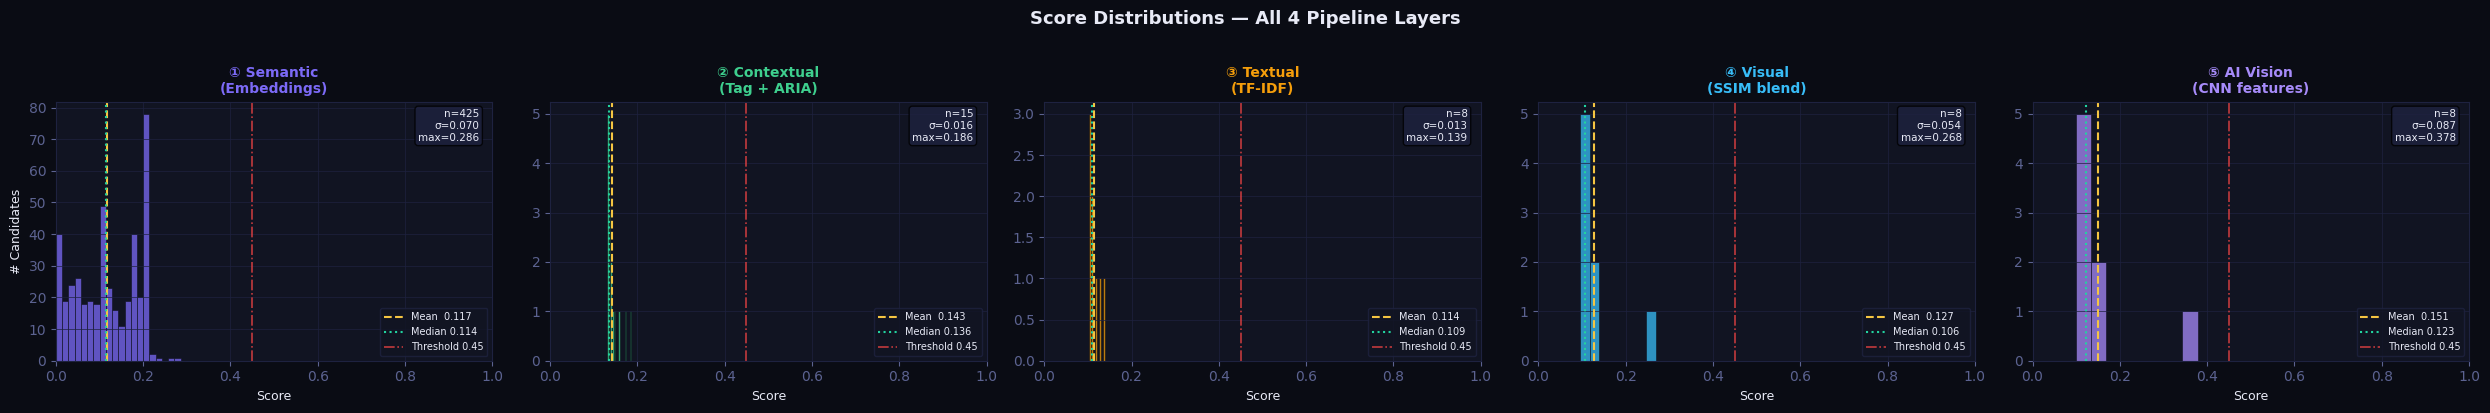

  → /content/fig1_distributions.png

[2/11] Candidate reduction funnel...


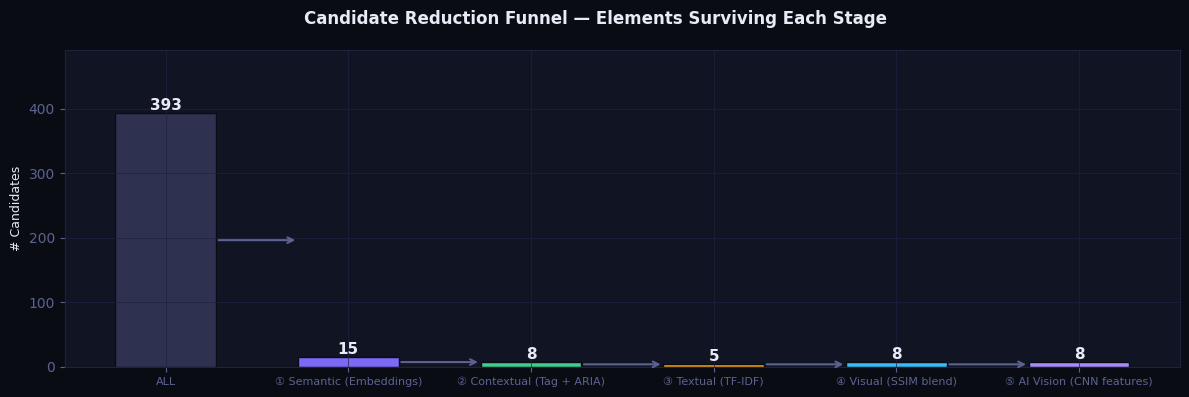

  → /content/fig2_funnel.png

[3/11] Score evolution across stages...


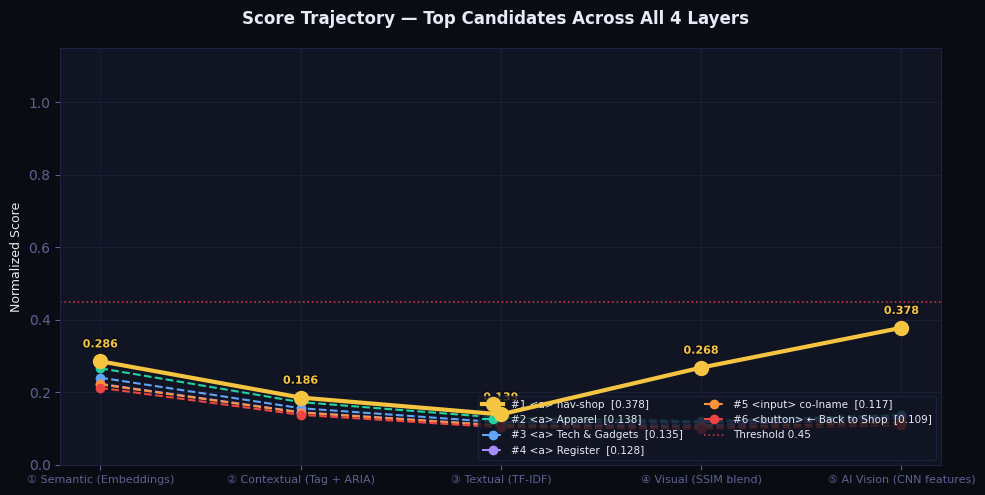

  → /content/fig3_score_evolution.png

[4/11] Score heatmap (all layers × top-10)...


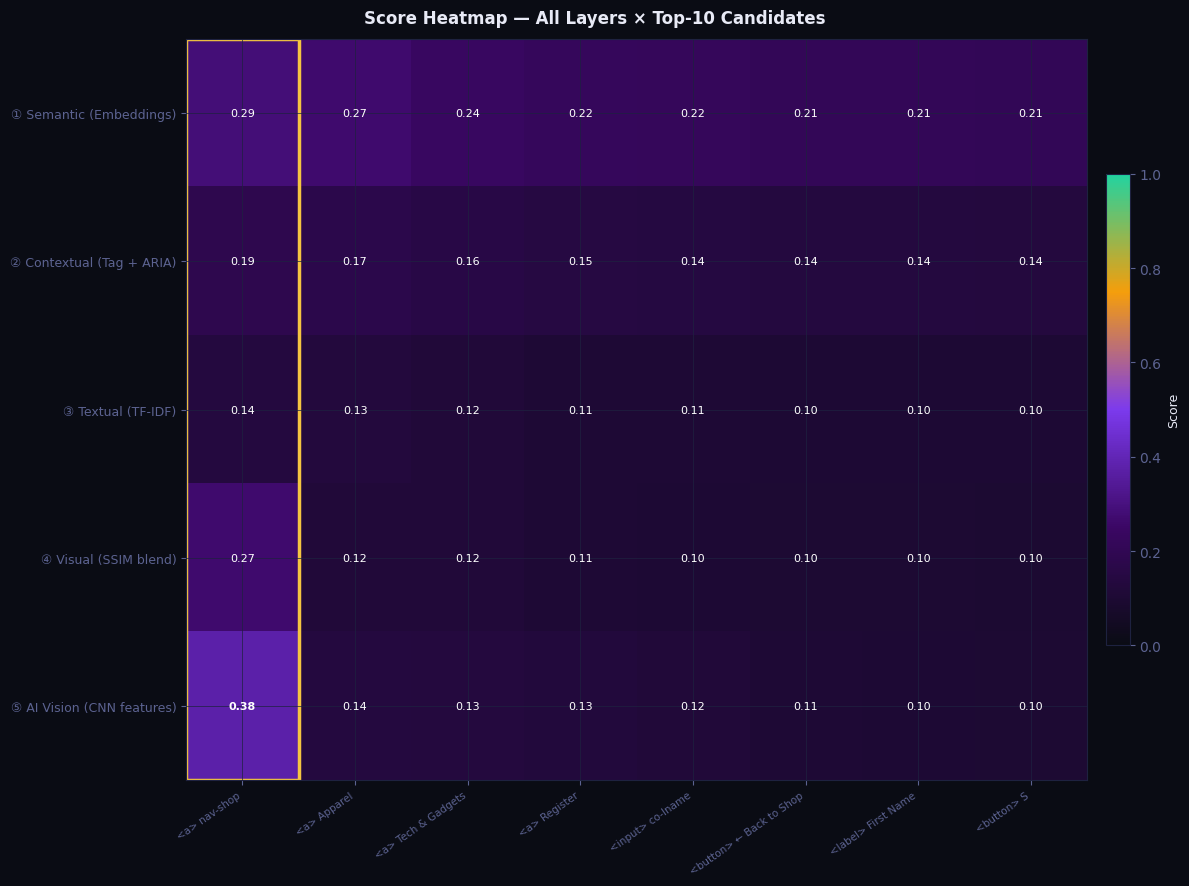

  → /content/fig4_heatmap.png

[5/11] Violin + box plots (distribution shape)...


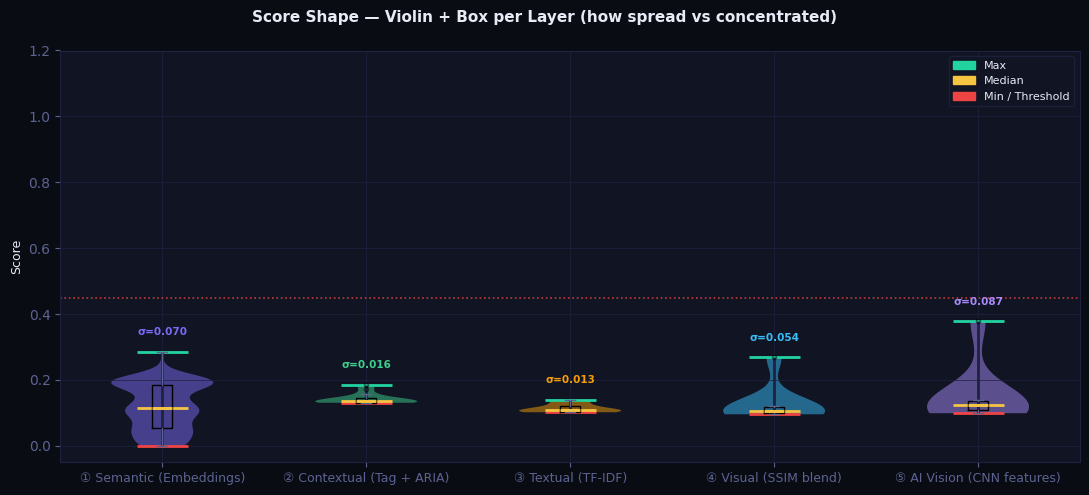

  → /content/fig5_violin.png

[6/11] Top-5 candidates + per-layer breakdown...


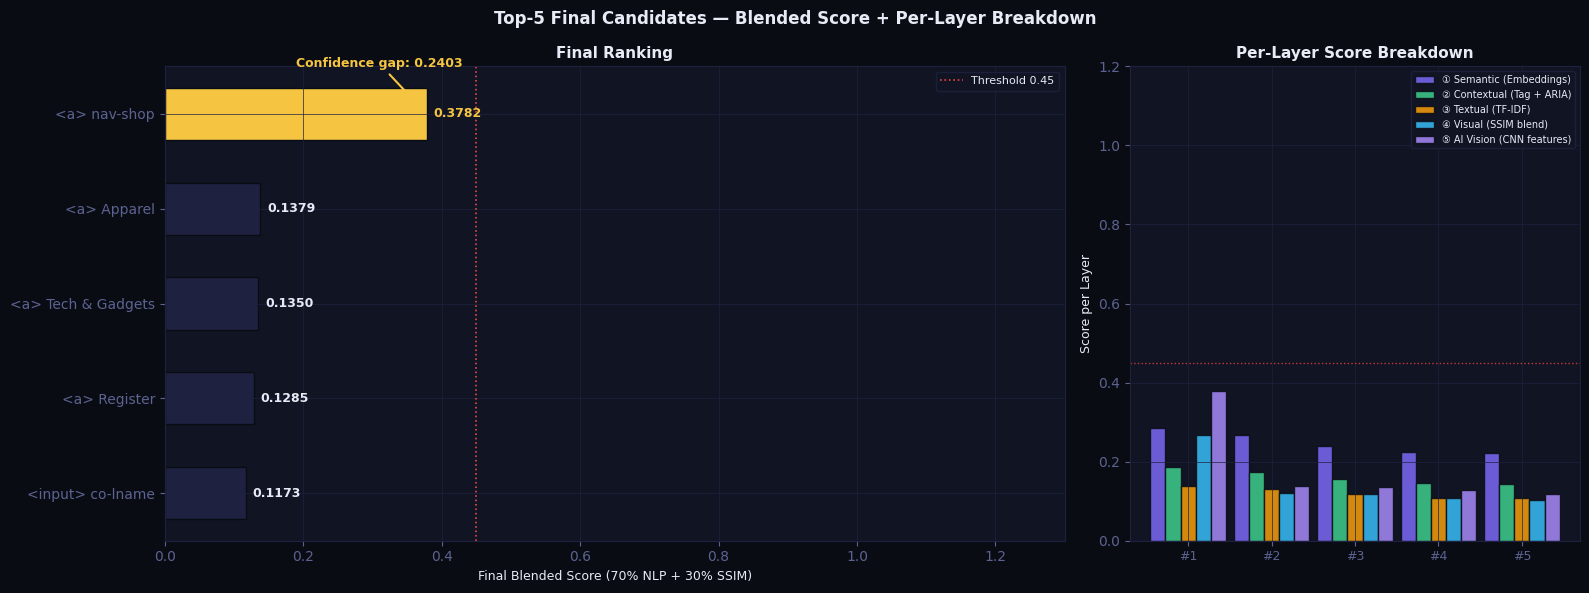

  → /content/fig6_top5.png

[7/11] Visual crops + SSIM maps...


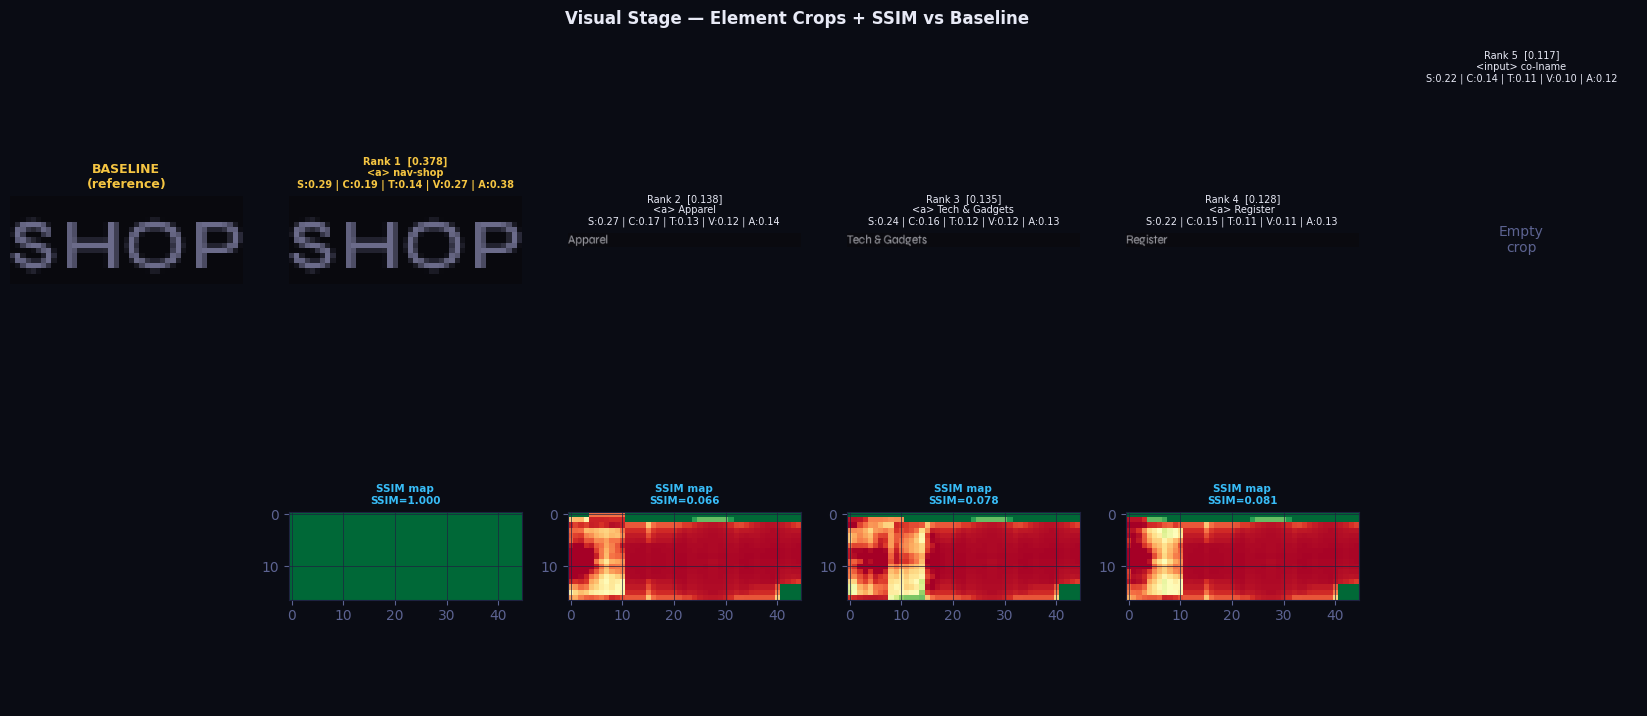

  → /content/fig7_visual_crops.png

[8/11] Score deltas between stages...


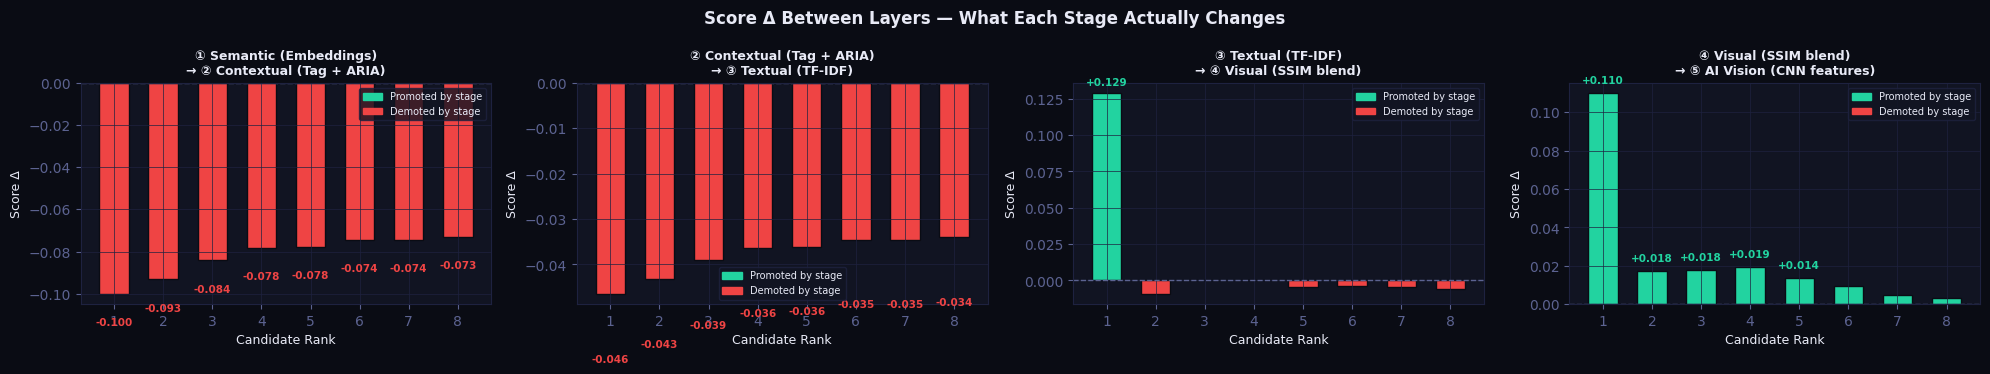

  → /content/fig8_score_deltas.png

[9/11] Full candidate ranking...


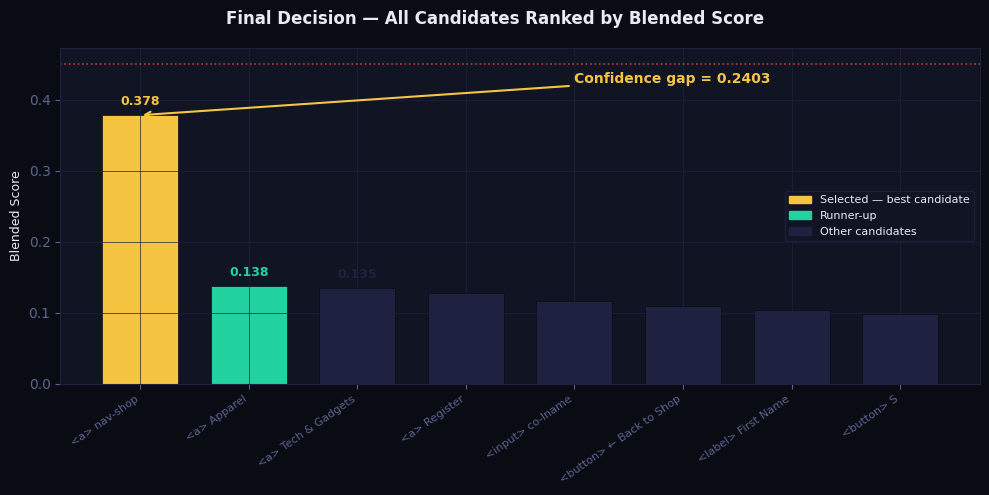

  → /content/fig9_full_ranking.png

[10/11] Annotated page screenshot...


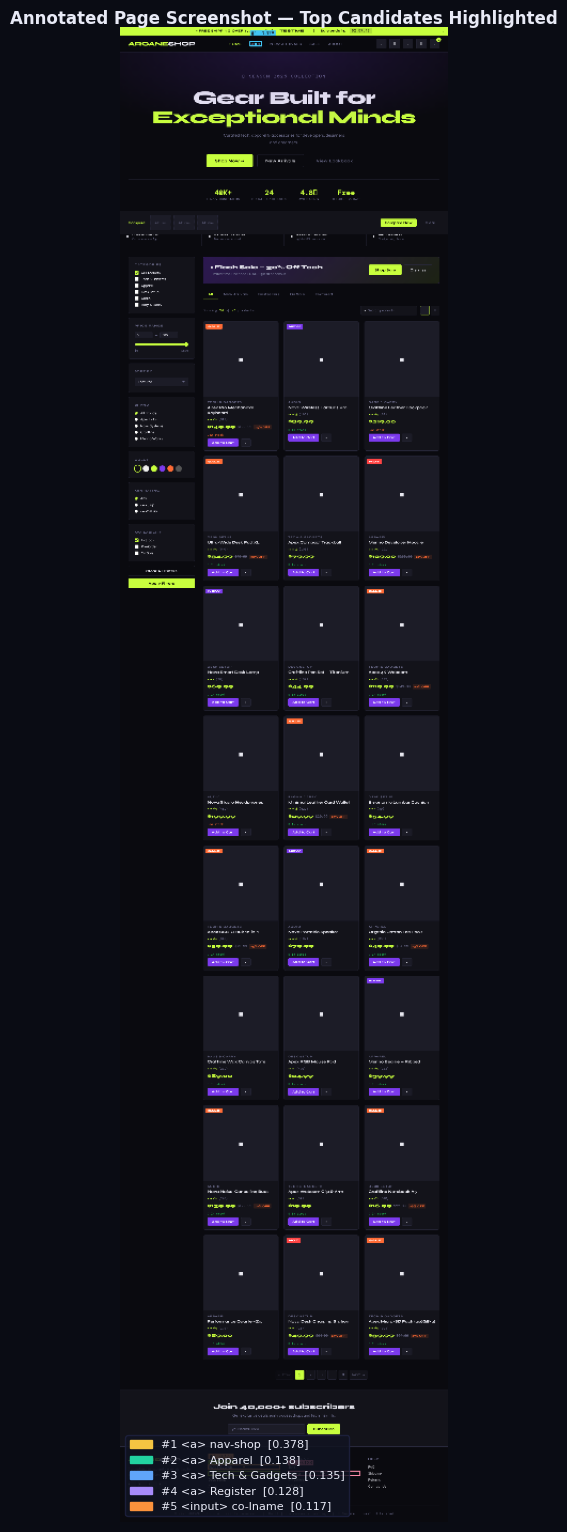

  → /content/fig10_annotated_screenshot.png

[11/11] Narrative decision card...


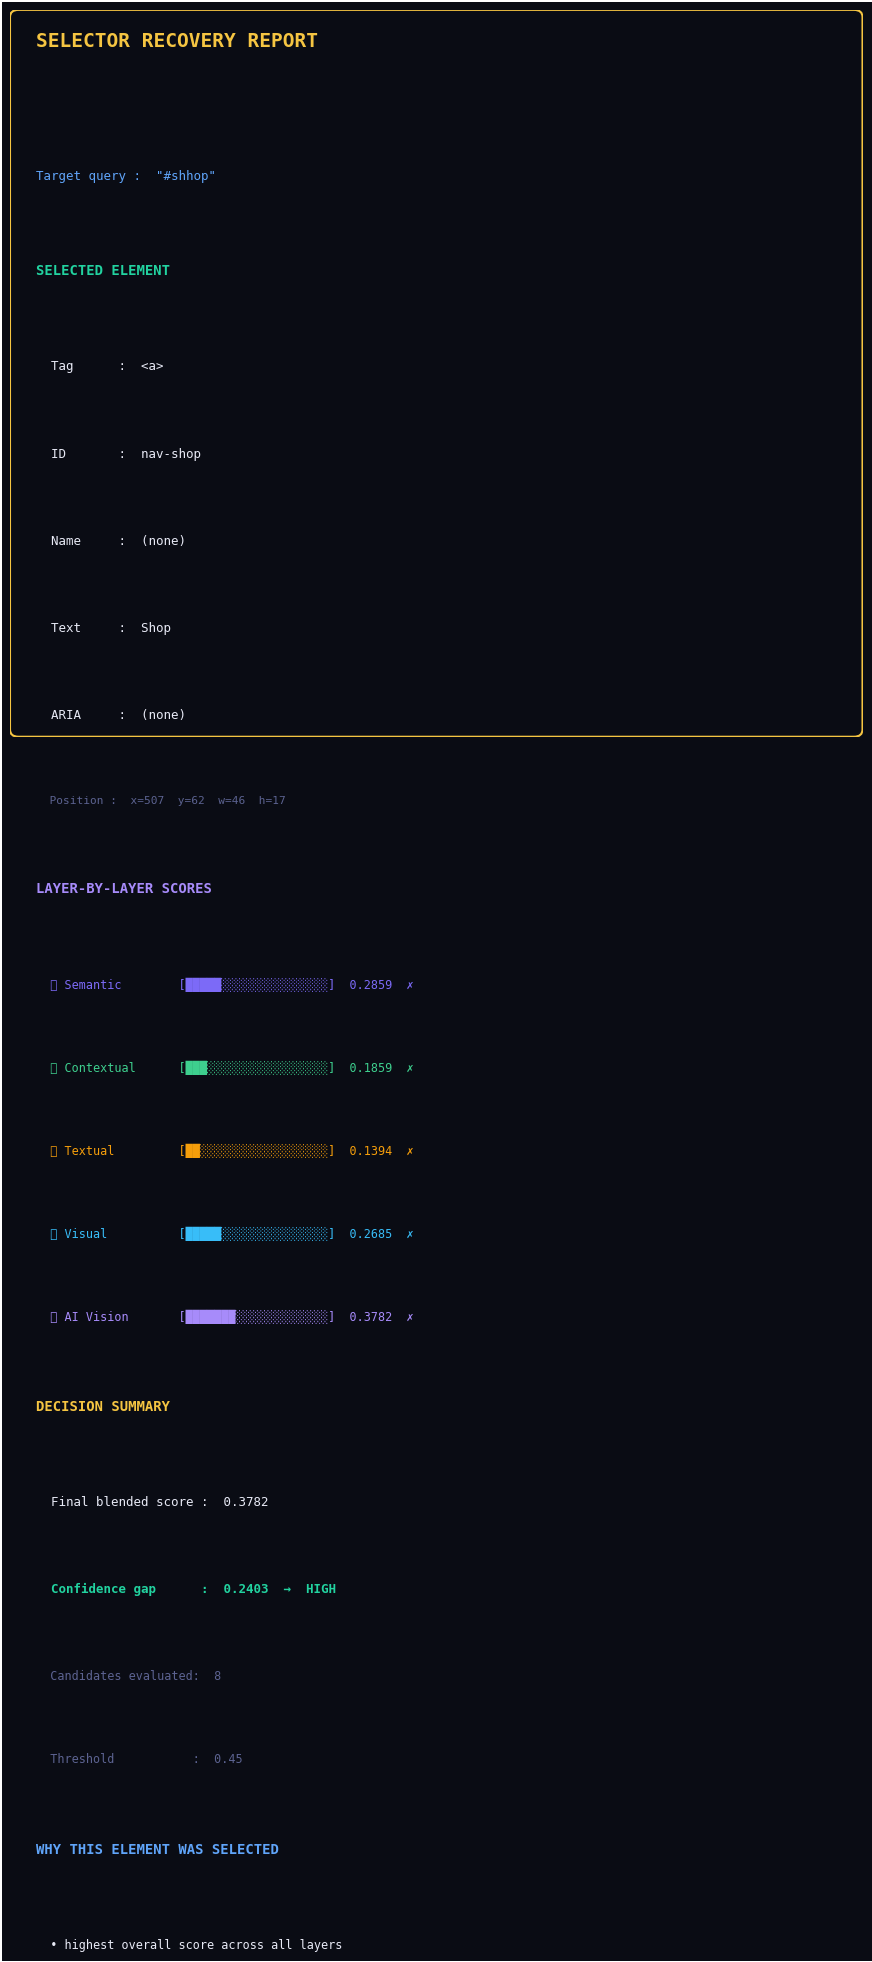

  → /content/fig11_narrative.png

  ✓ Dashboard complet (11.0s) — 11 figures sauvegardées
  Winner  : <a> nav-shop
  Score   : 0.3782
  Locator : page.locator("#nav-shop")



In [8]:
# Ensure generate_locators is available
from __main__ import generate_locators, run_pipeline
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 6 — FULL ANALYTICS DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
import os, cv2, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from skimage.metrics import structural_similarity as ssim
# ── THEME ─────────────────────────────────────────────────────────────────────
BG       = "#0a0c14"
PANEL    = "#111422"
BORDER   = "#1e2240"
TEXT_HI  = "#e8eaf6"
TEXT_LO  = "#5c6391"
GOLD     = "#f5c542"
RED      = "#ef4444"
GREEN    = "#22d3a0"
BLUE     = "#60a5fa"
PURPLE   = "#a78bfa"
ORANGE   = "#fb923c"
STAGE_COLORS = {
    "semantic":   "#7c6af7",
    "contextual": "#3ecf8e",
    "textual":    "#f59e0b",
    "visual":     "#38bdf8",
    "ai_vision":  "#a78bfa",
}
STAGE_LABELS = {
    "semantic":   "① Semantic\n(Embeddings)",
    "contextual": "② Contextual\n(Tag + ARIA)",
    "textual":    "③ Textual\n(TF-IDF)",
    "visual":     "④ Visual\n(SSIM blend)",
    "ai_vision":  "⑤ AI Vision\n(CNN features)",
}
STAGE_ORDER  = ["semantic", "contextual", "textual", "visual", "ai_vision"]
PALETTE = [GOLD, GREEN, BLUE, PURPLE, ORANGE, RED]
_plasma_dark = LinearSegmentedColormap.from_list(
    "plasma_dark", ["#0a0c14", "#3b0764", "#7c3aed", "#f59e0b", "#22d3a0"]
)
plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL,
    "axes.edgecolor":     BORDER,
    "axes.labelcolor":    TEXT_HI,
    "axes.titlecolor":    TEXT_HI,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "axes.labelsize":     9,
    "axes.grid":          True,
    "grid.color":         BORDER,
    "grid.linewidth":     0.5,
    "xtick.color":        TEXT_LO,
    "ytick.color":        TEXT_LO,
    "text.color":         TEXT_HI,
    "legend.facecolor":   PANEL,
    "legend.edgecolor":   BORDER,
    "legend.fontsize":    8,
    "lines.linewidth":    2,
})
CONF_THRESHOLD = 0.45
# ─────────────────────────────────────────────────────────────────────────────
#  HELPER : label court pour un élément
# ─────────────────────────────────────────────────────────────────────────────
def _el_label(el, max_len=20):
    eid = el.get("id","") or el.get("name","") or el.get("text"," ")
    return f"<{el.get('tag','')}> {eid[:max_len]}"
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 1 — STAGE SCORE DISTRIBUTIONS  (toutes les couches côte à côte)
# ─────────────────────────────────────────────────────────────────────────────
def plot_stage_distributions(history):
    active = [s for s in STAGE_ORDER if history.get(s)]
    if not active:
        print("  No stage data."); return
    fig, axes = plt.subplots(1, len(active), figsize=(5*len(active), 4), facecolor=BG)
    if len(active) == 1: axes = [axes]
    fig.suptitle("Score Distributions — All 4 Pipeline Layers", color=TEXT_HI, fontsize=13, fontweight="bold", y=1.02)
    for ax, stage in zip(axes, active):
        vals = np.array(history[stage])
        col  = STAGE_COLORS[stage]
        ax.hist(vals, bins=min(20, len(vals)), color=col, alpha=0.75,
                edgecolor=BG, linewidth=0.5)
        # Stats overlay
        mu, med, sd = vals.mean(), np.median(vals), vals.std()
        ax.axvline(mu,  color=GOLD,  lw=1.5, ls="--", label=f"Mean  {mu:.3f}")
        ax.axvline(med, color=GREEN, lw=1.5, ls=":",  label=f"Median {med:.3f}")
        ax.axvline(CONF_THRESHOLD, color=RED, lw=1.2, ls="-.", alpha=0.8, label=f"Threshold {CONF_THRESHOLD}")
        ax.set_title(STAGE_LABELS[stage], color=col, fontsize=10)
        ax.set_xlabel("Score")
        ax.set_ylabel("# Candidates" if stage == active[0] else "")
        ax.set_xlim(0, 1)
        ax.legend(fontsize=7)
        # Annotation box
        ax.text(0.97, 0.97, f"n={len(vals)}\nσ={sd:.3f}\nmax={vals.max():.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5, color=TEXT_HI,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=BORDER, alpha=0.8))
    plt.tight_layout()
    plt.savefig("/content/fig1_distributions.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig1_distributions.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 2 — FUNNEL  (combien de candidats passent chaque couche)
# ─────────────────────────────────────────────────────────────────────────────
def plot_funnel(history):
    CAPS = {"semantic": 15, "contextual": 8, "textual": 5, "visual": None, "ai_vision": None}
    active = [s for s in STAGE_ORDER if history.get(s)]
    if not active:
        print("  No funnel data."); return
    labels = ["ALL"] + [STAGE_LABELS[s].replace("\n", " ") for s in active]
    counts = [sum(1 for v in history[active[0]] if v > 0)]  # total visible
    for s in active:
        cap = CAPS[s]
        counts.append(min(len(history[s]), cap) if cap else len(history[s]))
    fig, ax = plt.subplots(figsize=(max(9, len(labels)*2), 4), facecolor=BG)
    ax.set_facecolor(PANEL)
    fig.suptitle("Candidate Reduction Funnel — Elements Surviving Each Stage", color=TEXT_HI, fontsize=12, fontweight="bold")
    bar_colors = ["#2e3250"] + [STAGE_COLORS[s] for s in active]
    bars = ax.bar(labels, counts, color=bar_colors, edgecolor=BG, width=0.55)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                str(cnt), ha="center", va="bottom", fontsize=11,
                color=TEXT_HI, fontweight="bold")
    # Arrows between bars
    for i in range(len(bars)-1):
        x1 = bars[i].get_x()   + bars[i].get_width()
        x2 = bars[i+1].get_x()
        y  = max(counts[i], counts[i+1]) / 2
        ax.annotate("", xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle="->", color=TEXT_LO, lw=1.5))
    ax.set_ylabel("# Candidates")
    ax.set_ylim(0, max(counts) * 1.25)
    ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    plt.savefig("/content/fig2_funnel.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig2_funnel.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 3 — SCORE EVOLUTION  (trajectoire de chaque candidat à travers les 4 couches)
# ─────────────────────────────────────────────────────────────────────────────
def plot_score_evolution(history, results, top_k=6):
    active = [s for s in STAGE_ORDER if history.get(s)]
    if not active:
        print("  No stage data for evolution."); return
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    fig.suptitle("Score Trajectory — Top Candidates Across All 4 Layers", color=TEXT_HI, fontsize=12, fontweight="bold")
    x_labels = [STAGE_LABELS[s].replace("\n", " ") for s in active]
    for i in range(min(top_k, len(results))):
        el, final_score = results[i]
        name = _el_label(el, 18)
        ys   = []
        for s in active:
            vals = history.get(s, [])
            ys.append(vals[i] if i < len(vals) else np.nan)
        lw = 3.0 if i == 0 else 1.5
        ms = 10  if i == 0 else 6
        ls = "-"  if i == 0 else "--"
        col = PALETTE[i % len(PALETTE)]
        ax.plot(x_labels, ys, marker="o", markersize=ms,
                color=col, lw=lw, ls=ls,
                label=f"#{i+1} {name}  [{final_score:.3f}]",
                zorder=10 if i == 0 else 5)
        # Score annotations on winner line
        if i == 0:
            for xi, (xl, yv) in enumerate(zip(x_labels, ys)):
                if not np.isnan(yv):
                    ax.annotate(f"{yv:.3f}", xy=(xi, yv), xytext=(0, 10),
                                textcoords="offset points",
                                fontsize=8, color=GOLD, fontweight="bold", ha="center",
                                path_effects=[pe.withStroke(linewidth=2, foreground=BG)])
    ax.axhline(CONF_THRESHOLD, color=RED, lw=1.2, ls=":", alpha=0.8, label=f"Threshold {CONF_THRESHOLD}")
    ax.set_ylabel("Normalized Score")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7.5, loc="lower right", ncol=2)
    ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    plt.savefig("/content/fig3_score_evolution.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig3_score_evolution.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 4 — HEATMAP  (stages × top-10, toutes les couches)
# ─────────────────────────────────────────────────────────────────────────────
def plot_score_heatmap(history, results):
    active = [s for s in STAGE_ORDER if history.get(s)]
    if not active:
        print("  No data for heatmap."); return
    top_n = min(10, len(results))
    matrix = np.array([
        history[s][:top_n] + [0.0] * (top_n - len(history[s][:top_n]))
        for s in active
    ])
    candidate_labels = [_el_label(el, 16) for el, _ in results[:top_n]]
    fig, ax = plt.subplots(figsize=(max(12, top_n*1.4), len(active)*1.5 + 1.5), facecolor=BG)
    ax.set_facecolor(PANEL)
    fig.suptitle("Score Heatmap — All Layers × Top-10 Candidates", color=TEXT_HI, fontsize=12, fontweight="bold")
    im = ax.imshow(matrix, aspect="auto", cmap=_plasma_dark, vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Score", color=TEXT_HI)
    cbar.ax.yaxis.set_tick_params(color=TEXT_LO)
    ax.set_yticks(range(len(active)))
    ax.set_yticklabels([STAGE_LABELS[s].replace("\n"," ") for s in active], fontsize=9)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(candidate_labels, rotation=35, ha="right", fontsize=7.5)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            txt_col = "white" if v < 0.6 else "#0a0c14"
            fw = "bold" if (i == len(active)-1 and j == 0) else "normal"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color=txt_col, fontweight=fw)
    # Highlight winner column
    ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, len(active),
                                fill=False, edgecolor=GOLD, lw=2.5))
    plt.tight_layout()
    plt.savefig("/content/fig4_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig4_heatmap.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 5 — VIOLIN + BOX  (distribution shape par couche)
# ─────────────────────────────────────────────────────────────────────────────
def plot_semantic_violin(history):
    active = [s for s in STAGE_ORDER if history.get(s)]
    if not active:
        print("  No data for violin."); return
    data   = [history[s] for s in active]
    labels = [STAGE_LABELS[s].replace("\n"," ") for s in active]
    colors = [STAGE_COLORS[s] for s in active]
    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    fig.suptitle("Score Shape — Violin + Box per Layer (how spread vs concentrated)", color=TEXT_HI, fontsize=11, fontweight="bold")
    parts = ax.violinplot(data, positions=range(len(data)), showmedians=True, showextrema=True)
    for pc, col in zip(parts["bodies"], colors):
        pc.set_facecolor(col); pc.set_alpha(0.5)
    parts["cmedians"].set_color(GOLD)
    parts["cmins"].set_color(RED)
    parts["cmaxes"].set_color(GREEN)
    parts["cbars"].set_color(BORDER)
    ax.boxplot(data, positions=range(len(data)), patch_artist=False, widths=0.1,
               medianprops=dict(color=GOLD, lw=2),
               whiskerprops=dict(color=TEXT_LO),
               capprops=dict(color=TEXT_LO),
               flierprops=dict(marker="o", markersize=3, color=RED, alpha=0.5))
    # Per-stage annotations
    for i, (stage, vals) in enumerate(zip(active, data)):
        arr = np.array(vals)
        ax.text(i, arr.max() + 0.05, f"σ={arr.std():.3f}", ha="center",
                fontsize=7.5, color=STAGE_COLORS[stage], fontweight="bold")
    ax.axhline(CONF_THRESHOLD, color=RED, lw=1.2, ls=":", alpha=0.8, label=f"Threshold {CONF_THRESHOLD}")
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.2)
    legend_patches = [
        mpatches.Patch(color=GREEN, label="Max"),
        mpatches.Patch(color=GOLD,  label="Median"),
        mpatches.Patch(color=RED,   label="Min / Threshold"),
    ]
    ax.legend(handles=legend_patches, fontsize=8)
    plt.tight_layout()
    plt.savefig("/content/fig5_violin.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig5_violin.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 6 — TOP-5  (barres horizontales avec scores de CHAQUE couche)
# ─────────────────────────────────────────────────────────────────────────────
def plot_top5(results, history):
    if not results:
        print("  No results."); return
    top5  = results[:5]
    n     = len(top5)
    active = [s for s in STAGE_ORDER if history.get(s)]
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, n*0.9 + 1.5)),
                             gridspec_kw={"width_ratios": [2, 1]}, facecolor=BG)
    fig.suptitle("Top-5 Final Candidates — Blended Score + Per-Layer Breakdown", color=TEXT_HI, fontsize=12, fontweight="bold")
    # Left: final horizontal bars
    ax = axes[0]
    ax.set_facecolor(PANEL)
    labels = [_el_label(el, 24) for el, _ in top5]
    scores = [s for _, s in top5]
    bar_colors = [GOLD] + [BORDER]*( n-1)
    hbars = ax.barh(labels[::-1], scores[::-1], color=bar_colors[::-1],
                    edgecolor=BG, height=0.55)
    for bar, val, col in zip(hbars, scores[::-1], bar_colors[::-1]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9,
                color=GOLD if col == GOLD else TEXT_HI, fontweight="bold")
    if len(scores) >= 2:
        gap = scores[0] - scores[1]
        ax.annotate(f"Confidence gap: {gap:.4f}",
                    xy=(scores[0], n-1),
                    xytext=(scores[0]*0.5, n-0.5),
                    fontsize=9, color=GOLD, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.5))
    ax.axvline(CONF_THRESHOLD, color=RED, lw=1.2, ls=":", label=f"Threshold {CONF_THRESHOLD}")
    ax.set_xlabel("Final Blended Score (70% NLP + 30% SSIM)")
    ax.set_xlim(0, 1.3)
    ax.legend(fontsize=8)
    ax.set_title("Final Ranking", color=TEXT_HI)
    # Right: per-layer scores for each top-5 candidate (grouped bars)
    ax2 = axes[1]
    ax2.set_facecolor(PANEL)
    ax2.set_title("Per-Layer Score Breakdown", color=TEXT_HI)
    x = np.arange(n)
    bar_w = 0.18
    for j, stage in enumerate(active):
        stage_scores = []
        for i in range(n):
            vals = history.get(stage, [])
            stage_scores.append(vals[i] if i < len(vals) else 0.0)
        ax2.bar(x + j*bar_w, stage_scores, bar_w,
                label=STAGE_LABELS[stage].replace("\n"," "),
                color=STAGE_COLORS[stage], edgecolor=BG, alpha=0.85)
    ax2.axhline(CONF_THRESHOLD, color=RED, lw=1, ls=":", alpha=0.8)
    ax2.set_xticks(x + bar_w*(len(active)-1)/2)
    ax2.set_xticklabels([f"#{i+1}" for i in range(n)], fontsize=9)
    ax2.set_ylabel("Score per Layer")
    ax2.set_ylim(0, 1.2)
    ax2.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.savefig("/content/fig6_top5.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig6_top5.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 7 — VISUAL CROPS  (captures des éléments candidats)
# ─────────────────────────────────────────────────────────────────────────────
def plot_visual_crops(results, full_img, history, top_k=5):
    n = min(top_k, len(results))
    if n == 0 or full_img is None:
        print("  No visual data."); return
    fig, axes = plt.subplots(2, n+1,
                             figsize=(3.5*(n+1), 8),
                             facecolor=BG,
                             gridspec_kw={"hspace": 0.05})
    fig.suptitle("Visual Stage — Element Crops + SSIM vs Baseline", color=TEXT_HI, fontsize=12, fontweight="bold")
    # Row 0 slot 0: baseline
    ax0 = axes[0][0]
    if os.path.exists("/content/baseline.png"):
        ref = cv2.imread("/content/baseline.png")
        ax0.imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
        ax0.set_title("BASELINE\n(reference)", color=GOLD, fontsize=9, fontweight="bold")
    else:
        ax0.text(0.5, 0.5, "No baseline\nimage", ha="center", va="center",
                 color=TEXT_LO, transform=ax0.transAxes)
        ax0.set_title("BASELINE", color=GOLD, fontsize=9)
    ax0.axis("off")
    axes[1][0].axis("off")
    h_img, w_img = full_img.shape[:2]
    for i, (el, score) in enumerate(results[:n]):
        ax_top = axes[0][i+1]
        ax_bot = axes[1][i+1]
        x = max(0, int(el["x"]))
        y = max(0, int(el["y"]))
        w = min(int(el["width"]),  w_img - x)
        h = min(int(el["height"]), h_img - y)
        crop = full_img[y:y+h, x:x+w] if (w > 0 and h > 0) else None
        if crop is not None and crop.size > 0:
            ax_top.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            ssim_str = ""
            if os.path.exists("/content/baseline.png"):
                ref = cv2.imread("/content/baseline.png")
                try:
                    c_r = cv2.resize(crop, (ref.shape[1], ref.shape[0]))
                    sv, ssim_map = ssim(ref, c_r, channel_axis=2, full=True)
                    ssim_str = f"SSIM={sv:.3f}"
                    # Row 1: SSIM diff map
                    diff = (ssim_map.mean(axis=2) if ssim_map.ndim==3 else ssim_map)
                    ax_bot.imshow(diff, cmap="RdYlGn", vmin=0, vmax=1)
                    ax_bot.set_title(f"SSIM map\n{ssim_str}", color=STAGE_COLORS["visual"], fontsize=7.5)
                except Exception:
                    ax_bot.axis("off")
            else:
                ax_bot.axis("off")
        else:
            ax_top.text(0.5, 0.5, "Empty\ncrop", ha="center", va="center",
                        color=TEXT_LO, transform=ax_top.transAxes)
            ax_bot.axis("off")
        # Per-layer scores in title
        stage_info = " | ".join(
            f"{s[0].upper()}:{history.get(s, [0]*10)[i]:.2f}"
            for s in STAGE_ORDER if history.get(s)
        )
        name  = el.get("id","") or el.get("name","") or el.get("text"," ")
        title = f"Rank {i+1}  [{score:.3f}]\n<{el.get('tag','')}> {name[:16]}\n{stage_info}"
        col   = GOLD if i == 0 else TEXT_HI
        ax_top.set_title(title, color=col, fontsize=7, fontweight="bold" if i==0 else "normal")
        ax_top.axis("off")
    plt.tight_layout()
    plt.savefig("/content/fig7_visual_crops.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig7_visual_crops.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 8 — SCORE DELTAS  (ce que chaque couche change)
# ─────────────────────────────────────────────────────────────────────────────
def plot_score_deltas(history):
    active = [s for s in STAGE_ORDER if history.get(s)]
    if len(active) < 2:
        print("  Not enough stages for delta plot."); return
    n_trans = len(active) - 1
    fig, axes = plt.subplots(1, n_trans, figsize=(5*n_trans, 4), facecolor=BG)
    if n_trans == 1: axes = [axes]
    fig.suptitle("Score Δ Between Layers — What Each Stage Actually Changes", color=TEXT_HI, fontsize=12, fontweight="bold")
    for ax, (s1, s2) in zip(axes, zip(active, active[1:])):
        n8  = 8
        sc1 = np.array(history[s1][:n8] + [0]*(n8 - len(history[s1][:n8])))
        sc2 = np.array(history[s2][:n8] + [0]*(n8 - len(history[s2][:n8])))
        deltas = sc2 - sc1
        ranks  = range(1, len(deltas)+1)
        colors = [GREEN if d >= 0 else RED for d in deltas]
        bars = ax.bar(ranks, deltas, color=colors, edgecolor=BG, width=0.6)
        for bar, d in zip(bars, deltas):
            if abs(d) > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + (0.005 if d >= 0 else -0.015),
                        f"{d:+.3f}", ha="center", fontsize=7.5,
                        color=GREEN if d >= 0 else RED, fontweight="bold")
        ax.axhline(0, color=TEXT_LO, lw=1, ls="--")
        s1_label = STAGE_LABELS[s1].replace("\n"," ")
        s2_label = STAGE_LABELS[s2].replace("\n"," ")
        ax.set_title(f"{s1_label}\n→ {s2_label}", color=TEXT_HI, fontsize=9)
        ax.set_xlabel("Candidate Rank")
        ax.set_ylabel("Score Δ")
        up   = mpatches.Patch(color=GREEN, label="Promoted by stage")
        down = mpatches.Patch(color=RED,   label="Demoted by stage")
        ax.legend(handles=[up, down], fontsize=7)
    plt.tight_layout()
    plt.savefig("/content/fig8_score_deltas.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig8_score_deltas.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 9 — FULL RANKING  (tous les candidats finaux)
# ─────────────────────────────────────────────────────────────────────────────
def plot_full_ranking(results):
    if not results:
        print("  No results."); return
    labels = [_el_label(el, 20) for el, _ in results]
    scores = [s for _, s in results]
    colors = [GOLD if i == 0 else GREEN if i == 1 else BORDER for i in range(len(scores))]
    fig, ax = plt.subplots(figsize=(max(10, len(scores)*0.9), 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    fig.suptitle("Final Decision — All Candidates Ranked by Blended Score", color=TEXT_HI, fontsize=12, fontweight="bold")
    bars = ax.bar(range(len(labels)), scores, color=colors,
                  edgecolor=BG, linewidth=0.5, width=0.7)
    for i in range(min(3, len(bars))):
        b = bars[i]
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{scores[i]:.3f}", ha="center", va="bottom",
                fontsize=9, color=colors[i], fontweight="bold")
    if len(results) >= 2:
        gap = scores[0] - scores[1]
        ax.annotate(f"Confidence gap = {gap:.4f}",
                    xy=(0, scores[0]),
                    xytext=(len(results)//2, max(scores)*1.12),
                    fontsize=10, color=GOLD, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.5))
    ax.axhline(CONF_THRESHOLD, color=RED, lw=1.2, ls=":", alpha=0.8, label=f"Threshold {CONF_THRESHOLD}")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Blended Score")
    ax.set_ylim(0, min(1.3, max(scores)*1.25))
    patches = [
        mpatches.Patch(color=GOLD,   label="Selected — best candidate"),
        mpatches.Patch(color=GREEN,  label="Runner-up"),
        mpatches.Patch(color=BORDER, label="Other candidates"),
    ]
    ax.legend(handles=patches, fontsize=8)
    plt.tight_layout()
    plt.savefig("/content/fig9_full_ranking.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig9_full_ranking.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 10 — ANNOTATED SCREENSHOT  (sélections dessinées sur la vraie page) ★ NEW
# ─────────────────────────────────────────────────────────────────────────────
def plot_annotated_screenshot(results, full_img, top_k=5):
    if full_img is None or not results:
        print("  No screenshot data."); return
    annotated = full_img.copy()
    h_img, w_img = annotated.shape[:2]
    n = min(top_k, len(results))
    COLORS_CV2 = [
        (245, 197, 66),   # GOLD  — winner
        (34,  211, 160),  # GREEN — 2nd
        (96,  165, 250),  # BLUE  — 3rd
        (167, 139, 250),  # PURPLE
        (251, 146, 60),   # ORANGE
    ]
    for i, (el, score) in enumerate(results[:n]):
        x = max(0, int(el["x"]))
        y = max(0, int(el["y"]))
        w = min(int(el["width"]),  w_img - x)
        h = min(int(el["height"]), h_img - y)
        if w < 5 or h < 5: continue
        col = COLORS_CV2[i % len(COLORS_CV2)]
        thick = 4 if i == 0 else 2
        # Rectangle
        cv2.rectangle(annotated, (x, y), (x+w, y+h), col, thick)
        # Rank badge
        badge_x, badge_y = x, max(0, y - 28)
        label = f"#{i+1}  {score:.3f}"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(annotated, (badge_x, badge_y - th - 4),
                      (badge_x + tw + 8, badge_y + 4), col, -1)
        cv2.putText(annotated, label, (badge_x + 4, badge_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (10, 12, 20), 1, cv2.LINE_AA)
        # Corner dot
        cv2.circle(annotated, (x + w//2, y + h//2), 5 if i == 0 else 3, col, -1)
    # Show in matplotlib
    # Scale down if page is very tall
    max_h = 1400
    if h_img > max_h:
        scale = max_h / h_img
        display = cv2.resize(annotated, (int(w_img*scale), max_h))
    else:
        display = annotated
    fig_h = display.shape[0] / 96 + 1
    fig_w = display.shape[1] / 96 + 1
    fig, ax = plt.subplots(figsize=(max(8, fig_w), max(6, fig_h)), facecolor=BG)
    ax.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    fig.suptitle("Annotated Page Screenshot — Top Candidates Highlighted", color=TEXT_HI, fontsize=12, fontweight="bold")
    # Legend
    legend_patches = [
        mpatches.Patch(color=np.array(COLORS_CV2[i%len(COLORS_CV2)])/255,
                       label=f"#{i+1} {_el_label(results[i][0], 22)}  [{results[i][1]:.3f}]")
        for i in range(n)
    ]
    ax.legend(handles=legend_patches, fontsize=8,
              loc="lower left", framealpha=0.85,
              facecolor=PANEL, edgecolor=BORDER)
    plt.tight_layout()
    plt.savefig("/content/fig10_annotated_screenshot.png", dpi=120, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig10_annotated_screenshot.png")
# ─────────────────────────────────────────────────────────────────────────────
#  FIG 11 — NARRATIVE CARD  (synthèse textuelle "pourquoi ce candidat") ★ NEW
# ─────────────────────────────────────────────────────────────────────────────
def plot_narrative_card(results, history, bt_expanded):
    if not results:
        print("  No results for narrative."); return
    best_el, best_score = results[0]
    active = [s for s in STAGE_ORDER if history.get(s)]
    # Per-layer scores for winner
    layer_scores = {}
    for s in active:
        vals = history.get(s, [])
        layer_scores[s] = vals[0] if vals else 0.0
    # Confidence
    gap = (results[0][1] - results[1][1]) if len(results) >= 2 else 0
    confidence = "HIGH" if gap > 0.15 else "MEDIUM" if gap > 0.05 else "LOW"
    conf_color = GREEN if gap > 0.15 else ORANGE if gap > 0.05 else RED
    # Build narrative lines
    lines = []
    lines.append(("SELECTOR RECOVERY REPORT", GOLD, 14, "bold"))
    lines.append(("", TEXT_HI, 1, "normal"))
    lines.append((f"Target query :  \"{bt_expanded}\"", BLUE, 9, "normal"))
    lines.append(("", TEXT_HI, 1, "normal"))
    lines.append(("SELECTED ELEMENT", GREEN, 10, "bold"))
    lines.append((f"  Tag      :  <{best_el.get('tag',' ')}>", TEXT_HI, 9, "normal"))
    lines.append((f"  ID       :  {best_el.get('id','') or '(none)'}", TEXT_HI, 9, "normal"))
    lines.append((f"  Name     :  {best_el.get('name','') or '(none)'}", TEXT_HI, 9, "normal"))
    lines.append((f"  Text     :  {(best_el.get('text','') or '')[:60] or '(none)'}", TEXT_HI, 9, "normal"))
    lines.append((f"  ARIA     :  {best_el.get('aria_label','') or '(none)'}", TEXT_HI, 9, "normal"))
    lines.append((f"  Position :  x={best_el.get('x',0):.0f}  y={best_el.get('y',0):.0f}  "
                  f"w={best_el.get('width',0):.0f}  h={best_el.get('height',0):.0f}", TEXT_LO, 8, "normal"))
    lines.append(("", TEXT_HI, 1, "normal"))
    lines.append(("LAYER-BY-LAYER SCORES", PURPLE, 10, "bold"))
    for s in active:
        sc = layer_scores[s]
        bar_filled = int(sc * 20)
        bar_str    = "█" * bar_filled + "░" * (20 - bar_filled)
        passed = "✓" if sc >= CONF_THRESHOLD else "✗"
        lines.append((f"  {STAGE_LABELS[s].split(chr(10))[0]:<16}  [{bar_str}]  {sc:.4f}  {passed}",
                      STAGE_COLORS[s], 8.5, "normal"))
    lines.append(("", TEXT_HI, 1, "normal"))
    lines.append(("DECISION SUMMARY", GOLD, 10, "bold"))
    lines.append((f"  Final blended score :  {best_score:.4f}", TEXT_HI, 9, "normal"))
    lines.append((f"  Confidence gap      :  {gap:.4f}  →  {confidence}", conf_color, 9, "bold"))
    lines.append((f"  Candidates evaluated:  {len(results)}", TEXT_LO, 8.5, "normal"))
    lines.append((f"  Threshold           :  {CONF_THRESHOLD}", TEXT_LO, 8.5, "normal"))
    lines.append(("", TEXT_HI, 1, "normal"))
    # WHY section
    reasons = []
    if layer_scores.get("semantic", 0) > 0.7:
        reasons.append("strong semantic similarity to target query")
    if layer_scores.get("contextual", 0) > 0.6:
        reasons.append("tag or ARIA label matched baseline text")
    if layer_scores.get("textual", 0) > 0.6:
        reasons.append("high TF-IDF overlap with query tokens")
    if layer_scores.get("visual", 0) > 0.6:
        reasons.append("visual region similar to baseline screenshot")
    if not reasons:
        reasons.append("highest overall score across all layers")
    lines.append(("WHY THIS ELEMENT WAS SELECTED", BLUE, 10, "bold"))
    for r in reasons:
        lines.append((f"  • {r}", TEXT_HI, 8.5, "normal"))
    # Draw
    fig_h = len(lines) * 0.32 + 0.8
    fig, ax = plt.subplots(figsize=(11, fig_h), facecolor=BG)
    ax.set_facecolor(PANEL)
    ax.axis("off")
    # Border
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.patch.set_linewidth(2)
    y_pos = 0.97
    for text, col, fs, fw in lines:
        if text == "":
            y_pos -= 0.01
            continue
        ax.text(0.03, y_pos, text, transform=ax.transAxes,
                fontsize=fs, color=col, fontweight=fw,
                fontfamily="monospace", va="top")
        y_pos -= (fs * 0.012 + 0.012)
    # Gold border rect
    rect = mpatches.FancyBboxPatch((0.01, 0.01), 0.98, 0.98,
                                    boxstyle="round,pad=0.01",
                                    linewidth=1.5, edgecolor=GOLD,
                                    facecolor="none", transform=ax.transAxes)
    ax.add_patch(rect)
    plt.tight_layout()
    plt.savefig("/content/fig11_narrative.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("  → /content/fig11_narrative.png")
# ─────────────────────────────────────────────────────────────────────────────
#  MAIN DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
def run_full_dashboard(results, full_img, history, bt_expanded=None):
    print("=" * 65)
    print("  FULL ANALYTICS DASHBOARD  — All Layers + Visual Annotations")
    print("=" * 65)
    if bt_expanded is None:
        bt_expanded = BASELINE_TEXT_EXPANDED if "BASELINE_TEXT_EXPANDED" in dir() else " "
    t0 = time.time()
    print("\n[1/11] Stage score distributions (all 4 layers)...")
    plot_stage_distributions(history)
    print("\n[2/11] Candidate reduction funnel...")
    plot_funnel(history)
    print("\n[3/11] Score evolution across stages...")
    plot_score_evolution(history, results)
    print("\n[4/11] Score heatmap (all layers × top-10)...")
    plot_score_heatmap(history, results)
    print("\n[5/11] Violin + box plots (distribution shape)...")
    plot_semantic_violin(history)
    print("\n[6/11] Top-5 candidates + per-layer breakdown...")
    plot_top5(results, history)
    print("\n[7/11] Visual crops + SSIM maps...")
    plot_visual_crops(results, full_img, history)
    print("\n[8/11] Score deltas between stages...")
    plot_score_deltas(history)
    print("\n[9/11] Full candidate ranking...")
    plot_full_ranking(results)
    print("\n[10/11] Annotated page screenshot...")
    plot_annotated_screenshot(results, full_img)
    print("\n[11/11] Narrative decision card...")
    plot_narrative_card(results, history, bt_expanded)
    elapsed = time.time() - t0
    best_el, best_score = results[0]
    print(f"\n{'='*65}")
    print(f"  ✓ Dashboard complet ({elapsed:.1f}s) — 11 figures sauvegardées")
    print(f"  Winner  : {_el_label(best_el, 40)}")
    print(f"  Score   : {best_score:.4f}")
    print(f"  Locator : {generate_locators(best_el)[0]['playwright'] if results else '—'}")
    print(f"{'='*65}\n")
# ── EXÉCUTION ──────────────────────────────────────────────────────────────────
if "global_results" in dir() and global_results:
    run_full_dashboard(
        global_results,
        global_img,
        global_history,
        bt_expanded=BASELINE_TEXT_EXPANDED if "BASELINE_TEXT_EXPANDED" in dir() else BASELINE_TEXT
    )
else:
    print("  ⚠  Lance Cell 5 d'abord pour peupler global_results / global_img / global_history.")

## Cell 8 — Flask API + Ngrok Static Tunnel (`arcane-healer`)

Set `NGROK_TOKEN` in Colab Secrets (🔑) before running. This creates a permanent URL at `https://arcane-healer.ngrok-free.app`.


In [9]:
#!pkill -f ngrok 2>/dev/null; sleep 2; ngrok kill 2>/dev/null; sleep 1

In [10]:
"""
!pkill -9 ngrok
!ngrok kill --all 2>/dev/null
"""

'\n!pkill -9 ngrok\n!ngrok kill --all 2>/dev/null\n'

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 8 — FLASK API + SQLite + NGROK STATIC TUNNEL
# ══════════════════════════════════════════════════════════════════════════════

from flask import Flask, request, jsonify, send_file, make_response
from flask_cors import CORS
import threading, asyncio, urllib.request, os, time, subprocess, re, psutil, difflib, shutil
from datetime import datetime
import sqlite3, json as _json
import sys
sys.path.insert(0, "/content")


# -- SQLite Database ---------------------------------------------------------
class HealDB:
    def __init__(self, path=None):
        if path is None:
            path = DB_PATH if "DB_PATH" in dir() else "/content/heal_history.db"
        self.path = path
        self._init_db()

    def _get_conn(self):
        conn = sqlite3.connect(self.path)
        conn.row_factory = sqlite3.Row
        return conn

    def _init_db(self):
        conn = self._get_conn()
        conn.executescript("CREATE TABLE IF NOT EXISTS runs (id INTEGER PRIMARY KEY AUTOINCREMENT, ts TEXT, broken_selector TEXT, healed_selector TEXT, strategy TEXT, status TEXT, confidence REAL, pipeline_time REAL, url TEXT, baseline_text TEXT, crop_url TEXT); CREATE TABLE IF NOT EXISTS candidates (id INTEGER PRIMARY KEY AUTOINCREMENT, run_id INTEGER, rank INTEGER, tag TEXT, el_id TEXT, blended_score REAL, semantic_score REAL, contextual_score REAL, tfidf_score REAL, ssim_score REAL, locator_type TEXT, stability TEXT, crop_url TEXT, FOREIGN KEY(run_id) REFERENCES runs(id)); CREATE TABLE IF NOT EXISTS stage_scores (id INTEGER PRIMARY KEY AUTOINCREMENT, run_id INTEGER, stage_name TEXT, scores TEXT, FOREIGN KEY(run_id) REFERENCES runs(id));")
        # Migrate existing DB: add crop_url columns if missing (safe to re-run)
        try:
            conn.execute("ALTER TABLE runs ADD COLUMN crop_url TEXT")
        except Exception:
            pass
        try:
            conn.execute("ALTER TABLE candidates ADD COLUMN crop_url TEXT")
        except Exception:
            pass
        conn.commit()
        conn.close()

    def insert_run(self, record, details=None):
        conn = self._get_conn()
        crop_url = record.get("crop_url", "")
        cur = conn.execute("INSERT INTO runs (ts, broken_selector, healed_selector, strategy, status, confidence, pipeline_time, url, baseline_text, crop_url) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)", (datetime.now().isoformat(), record.get("broken_selector",""), record.get("healed_selector",""), record.get("strategy",""), record.get("status",""), record.get("confidence",0.0), record.get("pipeline_time",0.0), record.get("url",""), record.get("baseline_text",""), crop_url))
        run_id = cur.lastrowid
        conn.commit()
        conn.close()
        return run_id

    def insert_candidates(self, run_id, candidates):
        conn = self._get_conn()
        for c in candidates:
            conn.execute("INSERT INTO candidates (run_id, rank, tag, el_id, blended_score, semantic_score, contextual_score, tfidf_score, ssim_score, locator_type, stability, crop_url) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)", (run_id, c.get("rank"), c.get("tag"), c.get("id"), c.get("blendedScore"), c.get("semanticScore"), c.get("contextualScore"), c.get("tfidfScore"), c.get("ssimScore"), c.get("locatorType"), c.get("stability"), c.get("cropUrl", "")))
        conn.commit()
        conn.close()

    def insert_stage_scores(self, run_id, history):
        conn = self._get_conn()
        for stage in ["semantic","contextual","textual","visual","ai_vision"]:
            scores = history.get(stage, [])
            if scores:
                conn.execute("INSERT INTO stage_scores (run_id, stage_name, scores) VALUES (?, ?, ?)", (run_id, stage, _json.dumps([float(s) for s in scores])))
        conn.commit()
        conn.close()

    def get_runs(self, limit=100, status=None):
        conn = self._get_conn()
        if status:
            rows = conn.execute("SELECT * FROM runs WHERE status=? ORDER BY id DESC LIMIT ?", (status, limit)).fetchall()
        else:
            rows = conn.execute("SELECT * FROM runs ORDER BY id DESC LIMIT ?", (limit,)).fetchall()
        conn.close()
        return [dict(r) for r in rows]

    def get_run(self, run_id):
        conn = self._get_conn()
        run = conn.execute("SELECT * FROM runs WHERE id=?", (run_id,)).fetchone()
        if not run:
            conn.close()
            return None
        run = dict(run)
        run["candidates"] = [dict(r) for r in conn.execute("SELECT * FROM candidates WHERE run_id=?", (run_id,)).fetchall()]
        run["stage_scores"] = {r["stage_name"]: _json.loads(r["scores"]) for r in conn.execute("SELECT * FROM stage_scores WHERE run_id=?", (run_id,)).fetchall()}
        conn.close()
        return run

    def delete_run(self, run_id):
        conn = self._get_conn()
        conn.execute("DELETE FROM candidates WHERE run_id=?", (run_id,))
        conn.execute("DELETE FROM stage_scores WHERE run_id=?", (run_id,))
        cur = conn.execute("DELETE FROM runs WHERE id=?", (run_id,))
        deleted = cur.rowcount > 0
        conn.commit()
        conn.close()
        return deleted

    def clear_all(self):
        conn = self._get_conn()
        conn.executescript("DELETE FROM candidates; DELETE FROM stage_scores; DELETE FROM runs;")
        conn.commit()
        conn.close()

    def get_analytics(self):
        conn = self._get_conn()
        total = conn.execute("SELECT COUNT(*) FROM runs").fetchone()[0]
        healed = conn.execute("SELECT COUNT(*) FROM runs WHERE status=?", ["healed"]).fetchone()[0]
        failed = conn.execute("SELECT COUNT(*) FROM runs WHERE status=?", ["failed"]).fetchone()[0]
        typo = conn.execute("SELECT COUNT(*) FROM runs WHERE strategy=?", ["typo"]).fetchone()[0]
        ml = conn.execute("SELECT COUNT(*) FROM runs WHERE strategy=?", ["ml"]).fetchone()[0]
        avg_conf =  conn.execute("SELECT AVG(confidence) FROM runs WHERE status=?", ["healed"]).fetchone()[0] or 0
        avg_time = conn.execute("SELECT AVG(pipeline_time) FROM runs").fetchone()[0] or 0
        conn.close()
        return {"total_runs": total, "healed": healed, "failed": failed, "typo_fixes": typo, "ml_fixes": ml, "avg_confidence": round(avg_conf, 4), "avg_pipeline_time": round(avg_time, 2), "success_rate": round((healed / total * 100) if total else 0, 1)}


db = HealDB()
last_run = None
last_run_id = 0
from flask_cors import CORS
app = Flask(__name__)
CORS(app, origins=["http://localhost:4200"])

global_stats = {"total_attempts": 0, "typo_fixes": 0, "ml_fixes": 0, "failed_heals": 0, "start_time": datetime.now().isoformat()}
healing_history = []


def get_ram_usage():
    ram = psutil.virtual_memory()
    return f"{ram.used / 1024**3:.1f}/{ram.total / 1024**3:.1f} GB"


# -- Locator builder ---------------------------------------------------------
def _build_locator(el):
    el_id = el.get("id", ""); el_testid = el.get("data_testid", ""); el_name = el.get("name", "")
    placeholder = el.get("placeholder", ""); aria_label = el.get("aria_label", ""); el_text = (el.get("text") or "").strip()
    tag = el.get("tag", "div"); el_class = el.get("class", ""); input_type = el.get("input_type", "")
    if el_id: return 'page.locator("#' + el_id + '")'
    if el_testid: return '[data-testid="' + el_testid + '"]'
    if el_name: return "page.locator(\"[name='" + el_name + "']\")"
    if placeholder: return 'page.get_by_placeholder("' + placeholder + '")'
    if aria_label: return 'page.get_by_label("' + aria_label + '")'
    role_map = {"button":"button","a":"link","select":"combobox","textarea":"textbox"}
    if tag == "input":
        if input_type in ("text","email","password","search","tel"): role_map["input"] = "textbox"
        elif input_type in ("checkbox","radio","submit","button"): role_map["input"] = input_type
    role = role_map.get(tag)
    if role and el_text: return 'page.get_by_role("' + role + '", name="' + el_text + '")'
    if el_text and len(el_text) > 1: return 'page.get_by_text("' + el_text + '", exact=True)'
    if el_class:
        classes = [c for c in el_class.split() if len(c) > 2 and c not in ("active","focus","hover","disabled","btn")][:2]
        if classes: return 'page.locator("' + tag + '.' + '.'.join(classes) + '")'
    return 'page.locator("' + tag + '").first'


# -- Build last_run ----------------------------------------------------------
def _build_last_run(results, history, pipeline_time, url, baseline_text):
    if not results:
        return {"best_score": 0.0, "total_candidates": 0, "pipeline_time": pipeline_time, "confidence_gap": 0.0, "winner": {}, "layers": [], "funnel": [], "candidates": [], "stage_counts": [], "stage_timings": [], "logs": []}
    best_el, best_score = results[0]
    second_score = results[1][1] if len(results) > 1 else 0.0
    confidence_gap = round(best_score - second_score, 4)
    stage_counts = history.get("stage_counts", [])
    stage_names = ["Semantic", "Contextual", "TF-IDF", "Visual", "AI Vision"]
    funnel = []
    if stage_counts:
        first_out = stage_counts[1] if len(stage_counts) > 1 else 1
        for i, name in enumerate(stage_names):
            if i + 1 >= len(stage_counts): break
            out_count = stage_counts[i + 1]
            pct = round((out_count / max(first_out, 1)) * 100)
            funnel.append({"name": name, "count": out_count, "pct": pct})
        stage_counts = stage_counts[1:]  # drop total elements count
    stage_key_map = [("semantic_raw","Semantic","NLP","#7c6af7"),("contextual_raw","Contextual","DOM","#3ecf8e"),("textual_raw","TF-IDF","Text","#f59e0b"),("visual","Visual","SSIM","#38bdf8"),("ai_vision","AI Vision","CNN","#a78bfa")]
    layers = []
    for key, name, label, color in stage_key_map:
        scores = history.get(key, [])
        if scores:
            layers.append({"name": name, "label": label, "score": round(float(scores[0]), 4), "color": color})
    n_stages = len(stage_counts) if stage_counts else 5
    base_time = pipeline_time / n_stages if n_stages else 0
    stage_timings = [round(base_time, 3)] * n_stages
    sem_scores = history.get("semantic_raw", []); ctx_scores = history.get("contextual_raw", []); txt_scores = history.get("textual_raw", []); vis_scores = history.get("visual", [])
    candidates_list = []
    for rank, (el, blended) in enumerate(results, 1):
        el_id = (el.get("id","") or el.get("name","") or el.get("text","")[:30])
        tag = el.get("tag","")
        loc_type = "ID" if el.get("id") else "Attr" if el.get("name") else "Class" if el.get("class") else "Text"
        stability = "high" if el.get("id") or el.get("name") else "medium" if el.get("aria_label") else "low"
        candidates_list.append({"rank": rank, "id": el_id, "tag": tag, "blendedScore": round(blended,4), "semanticScore": round(float(sem_scores[rank-1]) if rank-1 < len(sem_scores) else blended,4), "contextualScore": round(float(ctx_scores[rank-1]) if rank-1 < len(ctx_scores) else blended,4), "tfidfScore": round(float(txt_scores[rank-1]) if rank-1 < len(txt_scores) else blended,4), "ssimScore": round(float(vis_scores[rank-1]) if rank-1 < len(vis_scores) else blended,4), "locatorType": loc_type, "stability": stability, "bbox": {"x": el.get("x", 0), "y": el.get("y", 0), "width": el.get("width", 0), "height": el.get("height", 0)}, "cropUrl": f"/screenshot/crop/{rank}"})
    logs = ["[" + name + "] " + str(count) + " candidate(s)" for name, count in zip(stage_names, stage_counts)]
    best_el_id = (best_el.get("id") or best_el.get("name") or best_el.get("text","")[:40])
    logs.append("[Winner] " + _build_locator(best_el) + " @ " + str(round(best_score,4)))
    return {"best_score": round(best_score,4), "total_candidates": len(results), "pipeline_time": round(pipeline_time,3), "confidence_gap": confidence_gap, "winner": {"id": best_el_id, "locator": _build_locator(best_el)}, "layers": layers, "funnel": funnel, "candidates": candidates_list, "stage_counts": stage_counts, "stage_timings": stage_timings, "logs": logs}


# -- Selector boost filter ---------------------------------------------------
def _make_selector_boost(broken_selector):
    working = broken_selector.strip()
    if " " in working:
        working = working.rsplit(" ", 1)[1]
    import re as _re
    testid_m = _re.match(r"\[data-testid=[\"'](.+?)[\"']\]", working)
    if testid_m:
        broken_token = testid_m.group(1).lower()
    else:
        broken_token = working.lstrip("#. ").lower()
    if not broken_token:
        return None
    _BOOST_RATIO = 0.70
    def _boost(el):
        candidates = []
        el_id = el.get("id","")
        if el_id: candidates.append(el_id.lower())
        el_testid = el.get("data_testid","")
        if el_testid: candidates.append(el_testid.lower())
        el_class = el.get("class","")
        if el_class: candidates.extend(c.lower() for c in el_class.split() if c)
        for candidate in candidates:
            import difflib
            if difflib.SequenceMatcher(None, broken_token, candidate).ratio() >= _BOOST_RATIO:
                return True
        return False
    return _boost


# -- API Routes ----------------------------------------------------------------
@app.route('/dashboard-data', methods=['GET'])
def get_dashboard_data():
    locators_data = []
    try:
        recent = db.get_runs(limit=50)
        for r in recent:
            _run_id = r.get("id", 0)
            locators_data.append({
                "testName": r.get("url", r.get("broken_selector", "")),
                "brokenLocator": r.get("broken_selector", ""),
                "healedLocator": r.get("healed_selector", ""),
                "baselineText": r.get("baseline_text", ""),
                "confidence": r.get("confidence", None),
                "status": r.get("status", "failed"),
                "cropUrl": r.get("crop_url", None),
                "baselineUrl": f"/screenshot/baseline/{_run_id}" if _run_id else None,
            })
    except Exception:
        pass
    screenshot_info = None
    if os.path.exists("/content/fig10_annotated_screenshot.png"):
        # Use per-run baseline if last_run_id is known, otherwise fall back to global
        _bl_url = f"/screenshot/baseline/{last_run_id}" if last_run_id else "/screenshot/baseline"
        screenshot_info = {
            "annotated": "/screenshot/annotated",
            "baseline": _bl_url,
            "imageWidth": cv2.imread("/content/fig10_annotated_screenshot.png").shape[1],
            "imageHeight": cv2.imread("/content/fig10_annotated_screenshot.png").shape[0],
        }
    return jsonify({
        "stats": global_stats,
        "history": healing_history[:15],
        "system": {
            "ram": get_ram_usage(),
            "cpu": str(psutil.cpu_percent()) + "%",
            "server_status": "Active",
            "device": "Tesla T4 (Colab GPU)" if os.path.exists("/proc/driver/nvidia/version") else "CPU"
        },
        "lastRunDetails": {
            "bestScore": round(float(last_run["best_score"]),4) if last_run else 0,
            "totalCandidates": last_run["total_candidates"] if last_run else 0,
            "pipelineTimeSeconds": round(last_run["pipeline_time"],2) if last_run else 0,
            "confidenceGap": round(last_run["confidence_gap"],3) if last_run else 0,
            "winner": last_run["winner"] if last_run else {},
            "layers": last_run["layers"] if last_run else [],
            "funnel": last_run["funnel"] if last_run else [],
            "candidates": last_run["candidates"] if last_run else [],
            "locators": locators_data,
            "stageCounts": last_run["stage_counts"] if last_run else [],
            "stageTimings": last_run["stage_timings"] if last_run else [],
            "logs": last_run["logs"] if last_run else [],
            "screenshotInfo": screenshot_info
        }
    })




@app.route('/screenshot/annotated')
def serve_annotated_screenshot():
    path = '/content/fig10_annotated_screenshot.png'
    if os.path.exists(path):
        resp = make_response(send_file(path, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    return jsonify({'error': 'No annotated screenshot'}), 404


@app.route('/screenshot/baseline')
def serve_baseline_screenshot():
    path = '/content/baseline.png'
    if os.path.exists(path):
        resp = make_response(send_file(path, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    return jsonify({'error': 'No baseline screenshot'}), 404


@app.route('/screenshot/baseline/<int:run_id>')
def serve_baseline_for_run(run_id):
    _crop_dir = DRIVE_CROPS if "DRIVE_CROPS" in dir() else "/content"
    path = f'{_crop_dir}/{run_id}_baseline.png'
    if os.path.exists(path):
        resp = make_response(send_file(path, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    return jsonify({'error': 'Baseline not found for this run'}), 404


@app.route('/screenshot/crop/run/<int:run_id>')
def serve_run_crop(run_id):
    _crop_dir = DRIVE_CROPS if "DRIVE_CROPS" in dir() else "/content"
    path = f'{_crop_dir}/{run_id}.png'
    if os.path.exists(path):
        resp = make_response(send_file(path, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    # Fallback: check session crops
    fallback = f'/content/candidate_1.png'
    if os.path.exists(fallback):
        resp = make_response(send_file(fallback, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    return jsonify({'error': 'Crop not found for this run'}), 404


@app.route('/screenshot/crop/<int:rank>')
def serve_candidate_crop(rank):
    path = f'/content/candidate_{rank}.png'
    if os.path.exists(path):
        resp = make_response(send_file(path, mimetype='image/png'))
        resp.cache_control.max_age = 0
        resp.cache_control.no_cache = True
        return resp
    return jsonify({'error': 'Crop not found'}), 404
@app.route('/heal', methods=['POST'])
def heal():
    global last_run, global_stats, healing_history, last_run_id
    try:
        data = request.get_json(force=True)
        broken_selector   = data.get("broken_selector", "")
        url               = data.get("url", URL)
        baseline_text_req = data.get("baseline_text", BASELINE_TEXT)
        threshold         = float(data.get("confidence_threshold", CONFIDENCE_THRESHOLD))
        click_before      = data.get("click_before")
        skip_stages       = data.get("skip_stages", [])  # ablation: list of stage names to skip

        global_stats["total_attempts"] += 1
        t_start = time.time()

        if _is_garbage_selector(broken_selector):
            global_stats["failed_heals"] += 1
            return jsonify({"status": "failed", "healed_selector": "", "confidence": 0.0, "strategy": "ml", "pipelineTime": 0.0})

        loop = asyncio.new_event_loop()
        fixed_selector, fix_type, typo_ratio = loop.run_until_complete(
            typo_correct(broken_selector, url))
        loop.close()
        typo_ok = bool(fixed_selector and fixed_selector != broken_selector)
        print(f"  Typo result: fixed={fixed_selector!r} ratio={typo_ratio or 0:.3f} ok={typo_ok}")

        source_for_query = fixed_selector if typo_ok else broken_selector
        ml_query = selector_to_baseline_text(source_for_query)
        if baseline_text_req not in (BASELINE_TEXT, "#SHHOP", ""):
            ml_query = baseline_text_req
        if ml_query == source_for_query:
            ml_query = re.sub(r'[-_]', ' ', re.sub('^[#\.\[]|["\'\\\\]]', '', source_for_query)).strip()
        ml_query = expand_abbreviations(ml_query)
        # Fallback: if ml_query is empty, extract words from the raw selector
        if not ml_query or len(ml_query.strip()) < 2:
            _raw = re.sub(r'[-_]', ' ', re.sub('^[#\.\\[\]]|["\'\\\\]]', '', source_for_query)).strip()
            ml_query = _raw if _raw else source_for_query

        baseline_vec = get_embedding(ml_query)
        bt_expanded  = expand_abbreviations(ml_query)
#

        ml_confidence = 0.0
        results, full_img, history = [], None, {}
        if ml_query:
            boost_filter = _make_selector_boost(broken_selector)
            loop = asyncio.new_event_loop()
            results, full_img, history = loop.run_until_complete(
                run_pipeline(None, baseline_vec, bt_expanded, url=url,
                             selector_boost_filter=boost_filter,
                             click_before=click_before,
                             skip_stages=skip_stages))
            loop.close()

            # Save individual candidate crops (session + persistent)
            try:
                _im_h, _im_w = full_img.shape[:2]
                for _cr, (_el, _) in enumerate(results[:5], 1):
                    if not _el.get("visible", True):
                        continue
                    _cx = max(0, min(int(round(_el.get("x", 0))), _im_w - 1))
                    _cy = max(0, min(int(round(_el.get("y", 0))), _im_h - 1))
                    _cw = max(1, min(int(round(_el.get("width", 0))), _im_w - _cx))
                    _ch = max(1, min(int(round(_el.get("height", 0))), _im_h - _cy))
                    _crop = full_img[_cy:_cy+_ch, _cx:_cx+_cw]
                    # Session-level (backward compat, latest-run crop endpoint)
                    cv2.imwrite(f"/content/candidate_{_cr}.png", _crop)
            except Exception:
                pass
            # Save per-run winner crop to persistent storage
            _run_crop_url = ""
            try:
                if results:
                    _best_el, _ = results[0]
                    if _best_el.get("visible", True):
                        _bx = max(0, min(int(round(_best_el.get("x", 0))), _im_w - 1))
                        _by = max(0, min(int(round(_best_el.get("y", 0))), _im_h - 1))
                        _bw = max(1, min(int(round(_best_el.get("width", 0))), _im_w - _bx))
                        _bh = max(1, min(int(round(_best_el.get("height", 0))), _im_h - _by))
                        _bcrop = full_img[_by:_by+_bh, _bx:_bx+_bw]
                        _crop_dir = DRIVE_CROPS if "DRIVE_CROPS" in dir() else "/content"
                        os.makedirs(_crop_dir, exist_ok=True)
                        # run_id will be filled after insert; use a placeholder path
                        _run_crop_url = f"/screenshot/crop/run/__RUN_ID__"
            except Exception:
                pass
            try:
                plot_annotated_screenshot(results, full_img)
            except Exception:
                pass

            raw_ml        = results[0][1] if results else 0.0
            ml_confidence = round(raw_ml, 4)

        pipeline_time = time.time() - t_start
        ml_passed     = bool(results and ml_confidence >= threshold)
        ml_selector   = _build_locator(results[0][0]) if (results and ml_passed) else ""
        typo_ratio_f  = float(typo_ratio) if typo_ok else 0.0
        use_typo      = typo_ok

        if use_typo:
            strategy = "typo"; status = "healed"
            confidence = round(float(typo_ratio), 4); healed_selector = fixed_selector
            global_stats["typo_fixes"] += 1
        elif ml_passed:
            strategy = "ml"; status = "healed"
            confidence = round(ml_confidence, 4); healed_selector = ml_selector
            global_stats["ml_fixes"] += 1
        else:
            strategy = "ml"; status = "failed"
            confidence = round(ml_confidence, 4); healed_selector = ""
            global_stats["failed_heals"] += 1

        last_run = _build_last_run(results=results, history=history,
                                   pipeline_time=pipeline_time, url=url,
                                   baseline_text=baseline_text_req)
        _record = {
            "broken_selector": broken_selector, "healed_selector": healed_selector,
            "strategy": strategy, "status": status, "confidence": confidence,
            "pipeline_time": pipeline_time, "url": url, "baseline_text": baseline_text_req
        }
        # Save crop to persistent location with the real run_id
        if _run_crop_url and "__RUN_ID__" in _run_crop_url:
            pass  # run_id not yet known
        run_id = db.insert_run(_record, last_run)
        last_run_id = run_id
        if _run_crop_url:
            _crop_url = _run_crop_url.replace("__RUN_ID__", str(run_id))
            _record["crop_url"] = _crop_url
            try:
                if results:
                    _best_el, _ = results[0]
                    if _best_el.get("visible", True):
                        _bx = max(0, min(int(round(_best_el.get("x", 0))), _im_w - 1))
                        _by = max(0, min(int(round(_best_el.get("y", 0))), _im_h - 1))
                        _bw = max(1, min(int(round(_best_el.get("width", 0))), _im_w - _bx))
                        _bh = max(1, min(int(round(_best_el.get("height", 0))), _im_h - _by))
                        _bcrop = full_img[_by:_by+_bh, _bx:_bx+_bw]
                        _crop_dir = DRIVE_CROPS if "DRIVE_CROPS" in dir() else "/content"
                        _crop_path = f"{_crop_dir}/{run_id}.png"
                        cv2.imwrite(_crop_path, _bcrop)
                        # Update the DB record with crop_url
                        conn_upd = db._get_conn()
                        conn_upd.execute("UPDATE runs SET crop_url=? WHERE id=?", (_crop_url, run_id))
                        conn_upd.commit()
                        conn_upd.close()
            except Exception as crop_e:
                print(f"  [WARN] Could not save persistent crop: {crop_e}")
        # Save per-run baseline image persistently
        try:
            _baseline_path = "/content/baseline.png"
            if run_id and os.path.exists(_baseline_path):
                _crop_dir = DRIVE_CROPS if "DRIVE_CROPS" in dir() else "/content"
                os.makedirs(_crop_dir, exist_ok=True)
                shutil.copy2(_baseline_path, f"{_crop_dir}/{run_id}_baseline.png")
                _record["baseline_url"] = f"/screenshot/baseline/{run_id}"
        except Exception as bl_e:
            print(f"  [WARN] Could not save per-run baseline: {bl_e}")
        if last_run:
            db.insert_candidates(run_id, last_run.get("candidates", []))
            db.insert_stage_scores(run_id, history)
        _append_history(_record)
        return jsonify({
            "status": status, "healed_selector": healed_selector,
            "confidence": confidence, "strategy": strategy,
            "pipelineTime": pipeline_time, "run_id": run_id
        })

    except Exception as e:
        import traceback
        print(f"[/heal ERROR] {type(e).__name__}: {e}")
        print(traceback.format_exc())
        global_stats["failed_heals"] += 1
        return jsonify({
            "status": "error",
            "message": str(e),
            "healed_selector": "",
            "confidence": 0.0
        }), 500

@app.route('/history', methods=['GET'])
def get_history():
    limit = min(int(request.args.get("limit",100)),500)
    status = request.args.get("status")
    runs = db.get_runs(limit=limit, status=status or None)
    return jsonify({"runs": runs, "total": len(runs)})


@app.route('/history/<int:run_id>', methods=['GET'])
def get_history_run(run_id):
    run = db.get_run(run_id)
    if not run:
        return jsonify({"error":"not found"}),404
    return jsonify(run)


@app.route('/history/<int:run_id>', methods=['DELETE'])
def delete_history_run(run_id):
    deleted = db.delete_run(run_id)
    return jsonify({"deleted": deleted}), (200 if deleted else 404)




@app.route('/history/clear', methods=['DELETE'])
def clear_history():
    db.clear_all()
    return jsonify({"cleared": True})


@app.route('/analytics', methods=['GET'])
def get_analytics():
    return jsonify(db.get_analytics())


@app.route('/ping', methods=['GET'])
def ping():
    return jsonify({"status": "ok", "model": "all-MiniLM-L6-v2", "baseline": BASELINE_TEXT, "url": URL, "ram": get_ram_usage(), "db_path": db.path, "tunnel": "ngrok", "subdomain": "arcane-healer"})


def _append_history(record):
    global healing_history
    healing_history.insert(0, {"ts": datetime.now().isoformat(), "brokenSelector": record["broken_selector"], "healedSelector": record.get("healed_selector",""), "baselineText": record.get("baseline_text",""), "baselineUrl": record.get("baseline_url", None), "confidence": record["confidence"], "status": record["status"], "pipelineTime": record["pipeline_time"], "cropUrl": record.get("crop_url", None)})
    healing_history = healing_history[:15]


# -- STARTUP - Flask + Ngrok Static Tunnel -----------------------------------
from pyngrok import ngrok, conf as ngrok_conf

for proc in psutil.process_iter(["pid","name"]):
    try:
        for conn in proc.connections(kind="inet"):
            if conn.laddr.port == 5000:
                print("Killing stale process on port 5000: PID " + str(proc.pid) + " (" + proc.name() + ")")
                proc.kill()
    except (psutil.NoSuchProcess, psutil.AccessDenied):
        pass
time.sleep(1)

def _flask_thread():
    app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)

threading.Thread(target=_flask_thread, daemon=True).start()
time.sleep(2)

ngrok_conf.get_default().auth_token = NGROK_TOKEN
ngrok.kill()

try:
    public_url_obj = ngrok.connect(5000, hostname="laney-petaliferous-dully.ngrok-free.dev")
except Exception as ngrok_e:
    print(f"[ngrok] {ngrok_e}")
    print("[ngrok] Endpoint claimed -- using ephemeral URL instead")
    public_url_obj = ngrok.connect(5000)
public_url = public_url_obj.public_url.replace("http://", "https://")

print("")
print("=" * 50)
print(" API URL        : " + public_url)
print(" DB             : " + db.path)
print(" GET /history   : " + public_url + "/history")
print(" GET /analytics : " + public_url + "/analytics")
print(" GET /ping      : " + public_url + "/ping")
print(" POST /heal     : " + public_url + "/heal")
print("=" * 50)
print("")
print(" This URL is STATIC - paste it once in:")
print(" 1. Angular dashboard setup overlay")
print(" 2. .env.healing: COLAB_API_URL=https://laney-petaliferous-dully.ngrok-free.dev")


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



 API URL        : https://laney-petaliferous-dully.ngrok-free.dev
 DB             : /content/heal_history.db
 GET /history   : https://laney-petaliferous-dully.ngrok-free.dev/history
 GET /analytics : https://laney-petaliferous-dully.ngrok-free.dev/analytics
 GET /ping      : https://laney-petaliferous-dully.ngrok-free.dev/ping
 POST /heal     : https://laney-petaliferous-dully.ngrok-free.dev/heal

 This URL is STATIC - paste it once in:
 1. Angular dashboard setup overlay
 2. .env.healing: COLAB_API_URL=https://laney-petaliferous-dully.ngrok-free.dev


In [12]:
"""
!rm -f /content/drive/MyDrive/heal_data/heal_history.db
print("DB deleted - will be recreated with new schema")
"""

'\n!rm -f /content/drive/MyDrive/heal_data/heal_history.db\nprint("DB deleted - will be recreated with new schema")\n'